# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [2]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [3]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

DATA_PATH = r'..\data\raw\datasetOne.csv'
df = pd.read_csv(DATA_PATH, sep=',')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 4424 rows x 35 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
325,1,1,1,11,1,1,1,13,14,6,9,1,0,0,1,0,0,18,0,0,6,7,6,10.571429,0,0,6,11,3,11.666667,0,16.2,0.3,-0.92,Graduate
2812,1,8,5,12,1,1,1,1,1,5,4,1,0,0,1,0,0,18,0,0,7,7,7,13.190000,0,0,8,8,8,14.231250,0,11.1,0.6,2.02,Graduate
1968,1,8,1,16,1,1,1,1,1,4,5,0,0,1,1,0,0,18,0,0,6,8,4,13.250000,0,0,6,10,3,10.666667,0,12.7,3.7,-1.70,Enrolled
1417,1,8,1,14,1,1,1,3,14,6,6,0,0,0,1,0,0,18,0,0,6,6,6,13.666667,0,0,6,8,5,13.600000,0,8.9,1.4,3.51,Graduate
2814,1,1,1,2,1,1,1,3,28,3,11,1,0,0,1,0,0,18,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# Document data source details
data_source_report = {
    "source": "UCI Machine Learning Repository / Kaggle (https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success)",
    "acquisition_method": "CSV download",
    "date_acquired": "2026-03-07",  
    "issues_encountered": [
        "Windows path backslash formatting (resolved with raw string)",
        "Incorrect delimiter (switched from semicolon to comma)",
        "Initial KeyError for target columns due to parsing issues"
    ]
}
print(data_source_report)



{'source': 'UCI Machine Learning Repository / Kaggle (https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success)', 'acquisition_method': 'CSV download', 'date_acquired': '2026-03-07', 'issues_encountered': ['Windows path backslash formatting (resolved with raw string)', 'Incorrect delimiter (switched from semicolon to comma)', 'Initial KeyError for target columns due to parsing issues']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [6]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.


# 1. Volume: the size of the dataset
print("1. Dataset Volume:")
rows, cols = df.shape
print(f"Number of Records (Rows): {rows}")
print(f"Number of Attributes (Columns): {cols}\n")


1. Dataset Volume:
Number of Records (Rows): 4424
Number of Attributes (Columns): 35



In [7]:

# 2. Field Identities: column names, data types, and roles (feature vs. target)
print("2. Field Identities, Data Types, and Roles:")
print(df.info())

features = [col for col in df.columns if col != 'Target']
print(f"Target: {'Target'}")
print(f"Number of Features: {len(features)}")


2. Field Identities, Data Types, and Roles:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's

In [8]:

# 3. Descriptive Statistics: Numerical Features
print("\n3. Descriptive Statistics (Numerical)")
numerical_features = [
    'Application order', 'Age at enrollment', 
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

num_summary = df[numerical_features].describe().T 
num_summary['median'] = df[numerical_features].median() # Add median to the summary statistics
num_summary = num_summary[['mean', 'median', 'std', 'min', 'max']] # Reorder columns for better readability
print(num_summary)



3. Descriptive Statistics (Numerical)
                                                     mean     median  \
Application order                                1.727848   1.000000   
Age at enrollment                               23.265145  20.000000   
Curricular units 1st sem (credited)              0.709991   0.000000   
Curricular units 1st sem (enrolled)              6.270570   6.000000   
Curricular units 1st sem (evaluations)           8.299051   8.000000   
Curricular units 1st sem (approved)              4.706600   5.000000   
Curricular units 1st sem (grade)                10.640822  12.285714   
Curricular units 1st sem (without evaluations)   0.137658   0.000000   
Curricular units 2nd sem (credited)              0.541817   0.000000   
Curricular units 2nd sem (enrolled)              6.232143   6.000000   
Curricular units 2nd sem (evaluations)           8.063291   8.000000   
Curricular units 2nd sem (approved)              4.435805   5.000000   
Curricular units 2nd sem 

In [9]:

# 4. Descriptive Statistics: Categorical Features
print("\n4. Descriptive Statistics (Categorical)")

categorical_features = [
    'Marital status', 'Application mode', 'Course', 'Daytime/evening attendance', 
    'Previous qualification', 'Nacionality', "Mother's qualification", 
    "Father's qualification", "Mother's occupation", "Father's occupation", 
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 
    'Gender', 'Scholarship holder', 'International', 'Target'
]

for col in categorical_features:
    print(f"\nDistribution for: {col}")
    counts = df[col].value_counts() # Calculate absolute frequency
    percentages = df[col].value_counts(normalize=True) * 100  # Calculate relative frequency (percentage)
    # Combine into temporary DataFrame for clean output
    cat_summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })
    
    print(cat_summary)


4. Descriptive Statistics (Categorical)

Distribution for: Marital status
                Count  Percentage (%)
Marital status                       
1                3919           88.58
2                 379            8.57
4                  91            2.06
5                  25            0.57
6                   6            0.14
3                   4            0.09

Distribution for: Application mode
                  Count  Percentage (%)
Application mode                       
1                  1708           38.61
8                   872           19.71
12                  785           17.74
14                  312            7.05
15                  213            4.81
4                   139            3.14
9                   124            2.80
13                   77            1.74
16                   59            1.33
7                    38            0.86
17                   35            0.79
6                    30            0.68
3                    16  

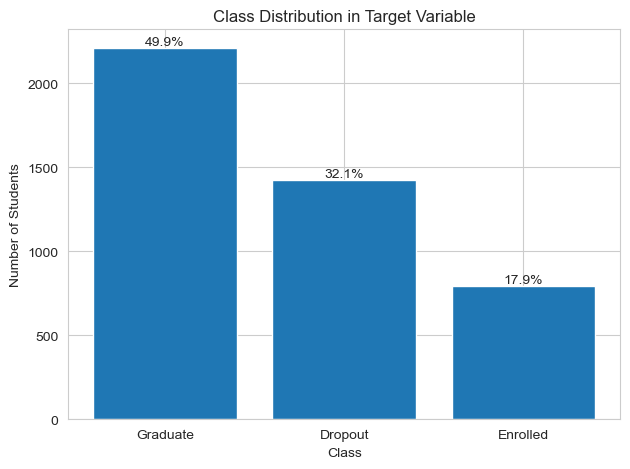

In [10]:

class_counts = df['Target'].value_counts()
total = len(df)

plt.figure()
bars = plt.bar(class_counts.index, class_counts.values)

# Add percentage labels
for i, v in enumerate(class_counts.values):
    plt.text(i, v, f"{(v/total)*100:.1f}%", ha='center', va='bottom')

plt.title("Class Distribution in Target Variable")
plt.xlabel("Class")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

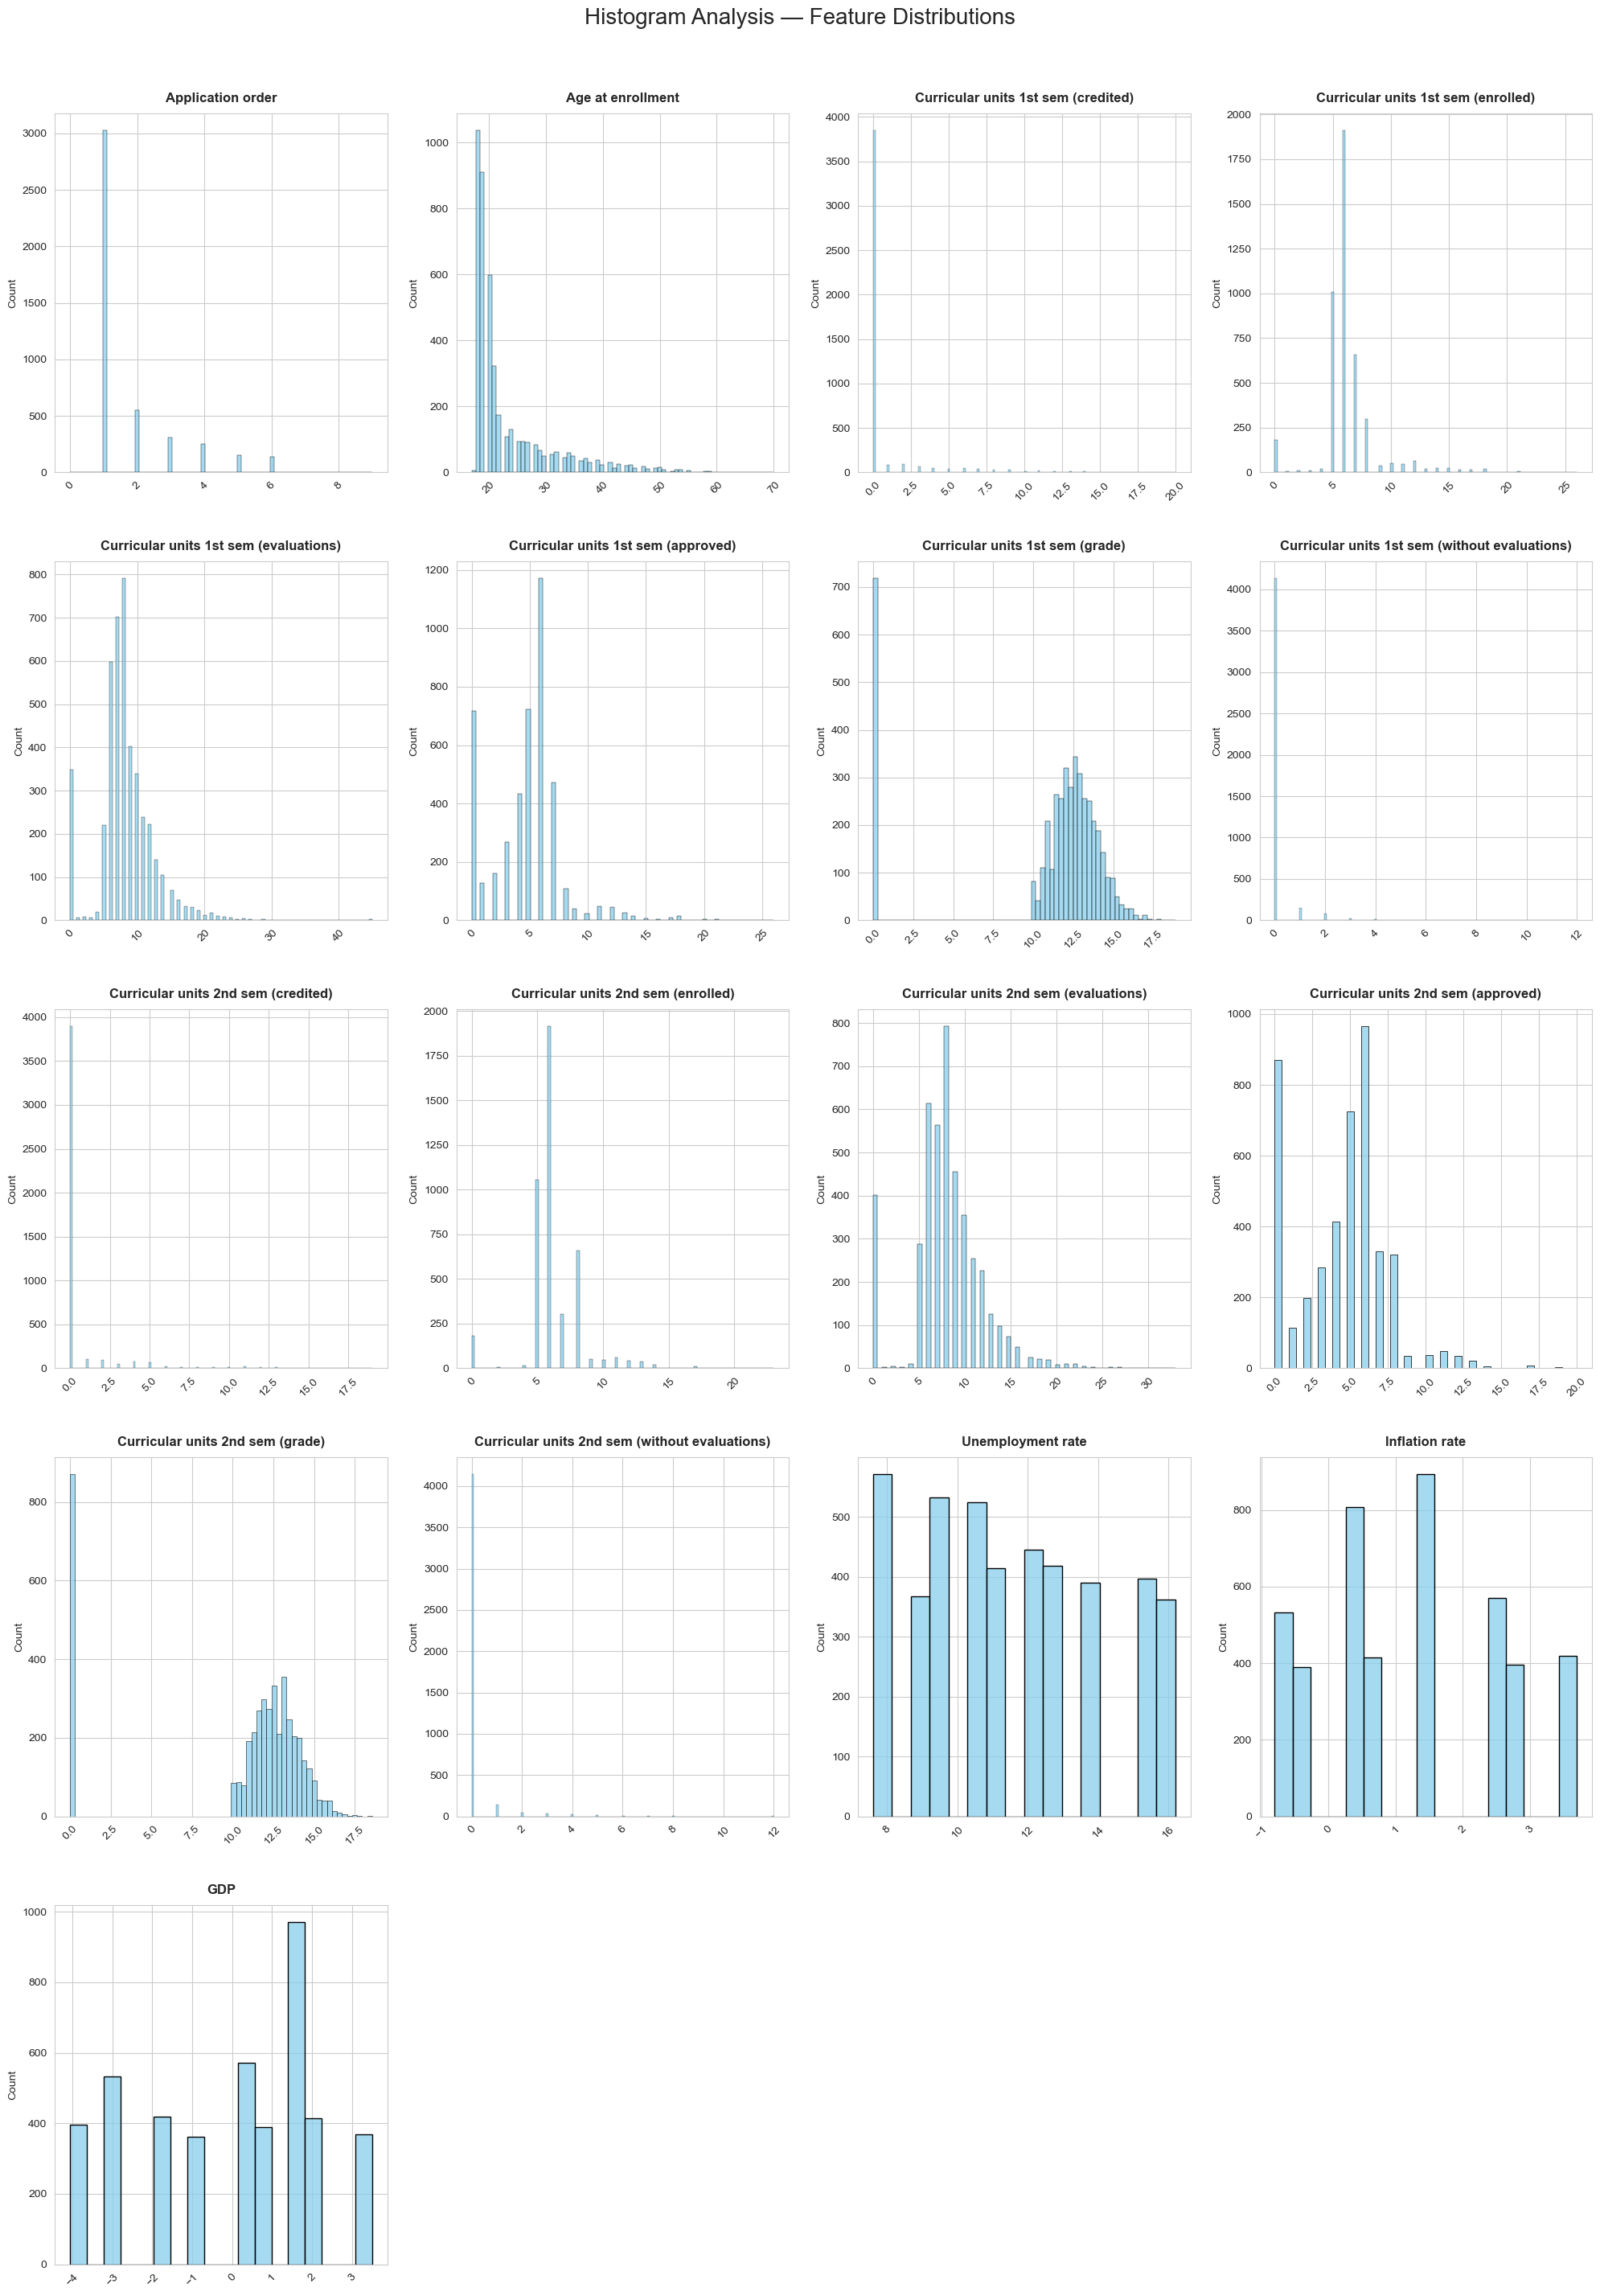

In [11]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

if numerical_features:
    n_cols = 4  # Reduced to 4 columns for better width per plot
    n_rows = (len(numerical_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 6 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numerical_features):
        sns.histplot(df[col].dropna(), ax=axes[i], kde=False, color='skyblue', edgecolor='black')
        
        # Formatting titles and labels
        axes[i].set_title(col, fontsize=12, fontweight='bold', pad=10)
        axes[i].set_xlabel('') # Clear x-label to reduce clutter
        axes[i].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap
        
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
  
    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=4.0, w_pad=2.0)
    
    plt.suptitle('Histogram Analysis — Feature Distributions', fontsize=20, y=0.98)
    plt.show()

In [12]:
histograms_insights = {
    "1. Application order": 
        """Observation: Highly right-skewed distribution with a massive peak at the first preference (1), followed by a steep drop-off.
        Key Insight: Most students are highly intentional, applying for their primary course choice. Lower frequency for higher orders suggests these may be 'fallback' applications.
        Phase 3 Action: Treat as a categorical ordinal feature; consider grouping values >3 into an 'Other' category to reduce sparsity.""",

    "2. Age at enrollment": 
        """Observation: Strongly right-skewed with a peak at 18-20 years and a long tail extending to 60+.
        Key Insight: The dataset is dominated by traditional-age students, but the long tail indicates a significant population of mature learners.
        Phase 3 Action: Apply Log Transformation to normalize the skew or bin into 'Traditional', 'Adult', and 'Senior' learners to handle non-linear risk.""",

    "3. Curricular units 1st sem (credited)": 
        """Observation: Extremely sparse distribution with nearly all values at 0; very few students have credited units.
        Key Insight: Most students are starting fresh without prior recognized higher education credits.
        Phase 3 Action: Convert to a binary 'has_credits' flag (0 or 1) as the raw count has insufficient variance for most models.""",

    "4. Curricular units 1st sem (enrolled)": 
        """Observation: Multi-modal distribution with a primary peak around 5-7 units.
        Key Insight: Standard enrollment patterns are clearly visible, representing the institution's typical full-time course load.
        Phase 3 Action: Use as a baseline for academic load; check for high-leverage outliers who are significantly over-enrolled.""",

    "5. Curricular units 1st sem (evaluations)": 
        """Observation: Approximately normal distribution centered around 7-10 exams, but with a notable tail on the right.
        Key Insight: Evaluation frequency is more varied than enrollment, showing differences in student exam-taking behavior.
        Phase 3 Action: Retain as a continuous feature to measure academic engagement and participation levels.""",

    "6. Curricular units 1st sem (approved)": 
        """Observation: Bi-modal distribution with peaks at 0 and 6 units.
        Key Insight: This is a critical separator. Students tend to either pass almost everything or pass nothing at all.
        Phase 3 Action: Weight heavily in Phase 4; investigate the 'Zero-Approved' group as it likely maps directly to the Dropout target.""",

    "7. Curricular units 1st sem (grade)": 
        """Observation: Normal distribution centered near 12-13, but with a significant isolated spike at 0.
        Key Insight: The spike at 0 represents total academic failure, which is distinct from a 'low' passing grade (e.g., 10).
        Phase 3 Action: Handle the 0-spike separately by creating a 'Grade_is_Zero' binary feature to prevent the mean from being skewed.""",

    "8. Curricular units 1st sem (without evaluations)": 
        """Observation: Nearly all values are 0, with a few negligible counts at 1 or 2.
        Key Insight: Almost every student attempts at least one evaluation for their enrolled units.
        Phase 3 Action: Likely a candidate for removal due to near-zero variance unless it shows high importance in a tree-based model.""",

    "9. Curricular units 2nd sem (credited)": 
        """Observation: Mirroring the 1st semester, this is extremely sparse and centered at 0.
        Key Insight: Credit recognition is an entry-level event that does not change between semesters for most students.
        Phase 3 Action: Drop this feature if it highly correlates with 1st sem credited units to reduce dimensionality.""",

    "10. Curricular units 2nd sem (enrolled)": 
        """Observation: Multi-modal, consistent with the 1st semester enrollment peak around 5-7.
        Key Insight: Enrollment stays stable across the academic year for the majority of the student body.
        Phase 3 Action: Cross-reference with 1st sem enrollment to identify students who 'downsized' their load in the 2nd semester.""",

    "11. Curricular units 2nd sem (evaluations)": 
        """Observation: Slightly more skewed than 1st sem evaluations, centered around 8-10.
        Key Insight: Exam participation remains high but shows more variability in the second semester.
        Phase 3 Action: Retain as a raw count; useful for calculating engagement trends over time.""",

    "12. Curricular units 2nd sem (approved)": 
        """Observation: Strong peaks at 0 and 5-6; very high frequency at 0.
        Key Insight: Second-semester success is the definitive moment for many students. The 0-approval peak is more pronounced than in the 1st semester.
        Phase 3 Action: This is your 'Star Feature'—ensure it is not scaled in a way that loses the distinction of the 0-peak.""",

    "13. Curricular units 2nd sem (grade)": 
        """Observation: Normal distribution around 12, with a larger 0-spike compared to the 1st semester.
        Key Insight: Demonstrates 'performance decay'—students who failed in sem 1 are even more likely to have a 0 in sem 2.
        Phase 3 Action: Combine with 1st sem grade to create a 'Semester_Grade_Delta' feature to track performance trends.""",

    "14. Curricular units 2nd sem (without evaluations)": 
        """Observation: Sparse distribution centered at 0, similar to the first semester.
        Key Insight: Most students continue to attempt evaluations for their enrolled units.
        Phase 3 Action: Check for correlation with 1st sem without evaluations; remove if redundant.""",

    "15. Unemployment rate": 
        """Observation: Discrete distribution with several distinct peaks between 7% and 16%.
        Key Insight: Represents macro-economic snapshots at enrollment. The lack of a smooth distribution indicates data collected at specific intervals.
        Phase 3 Action: Treat as a continuous feature but monitor for low importance in final model evaluations.""",

    "16. Inflation rate": 
        """Observation: Relatively uniform distribution with peaks across the range of -1 to 3.
        Key Insight: Inflation shows more variance than GDP/Unemployment but lacks a strong central tendency.
        Phase 3 Action: Retain for now; however, previous heatmap analysis suggests this feature may be noise.""",

    "17. GDP": 
        """Observation: Discrete distribution with a strong peak near 0-1 and smaller peaks at the extremes (-4 and 3.5).
        Key Insight: Most students enrolled during periods of modest economic growth.
        Phase 3 Action: Keep as is; useful for testing if economic recession periods (-4.0) correlate with higher dropout rates."""
}

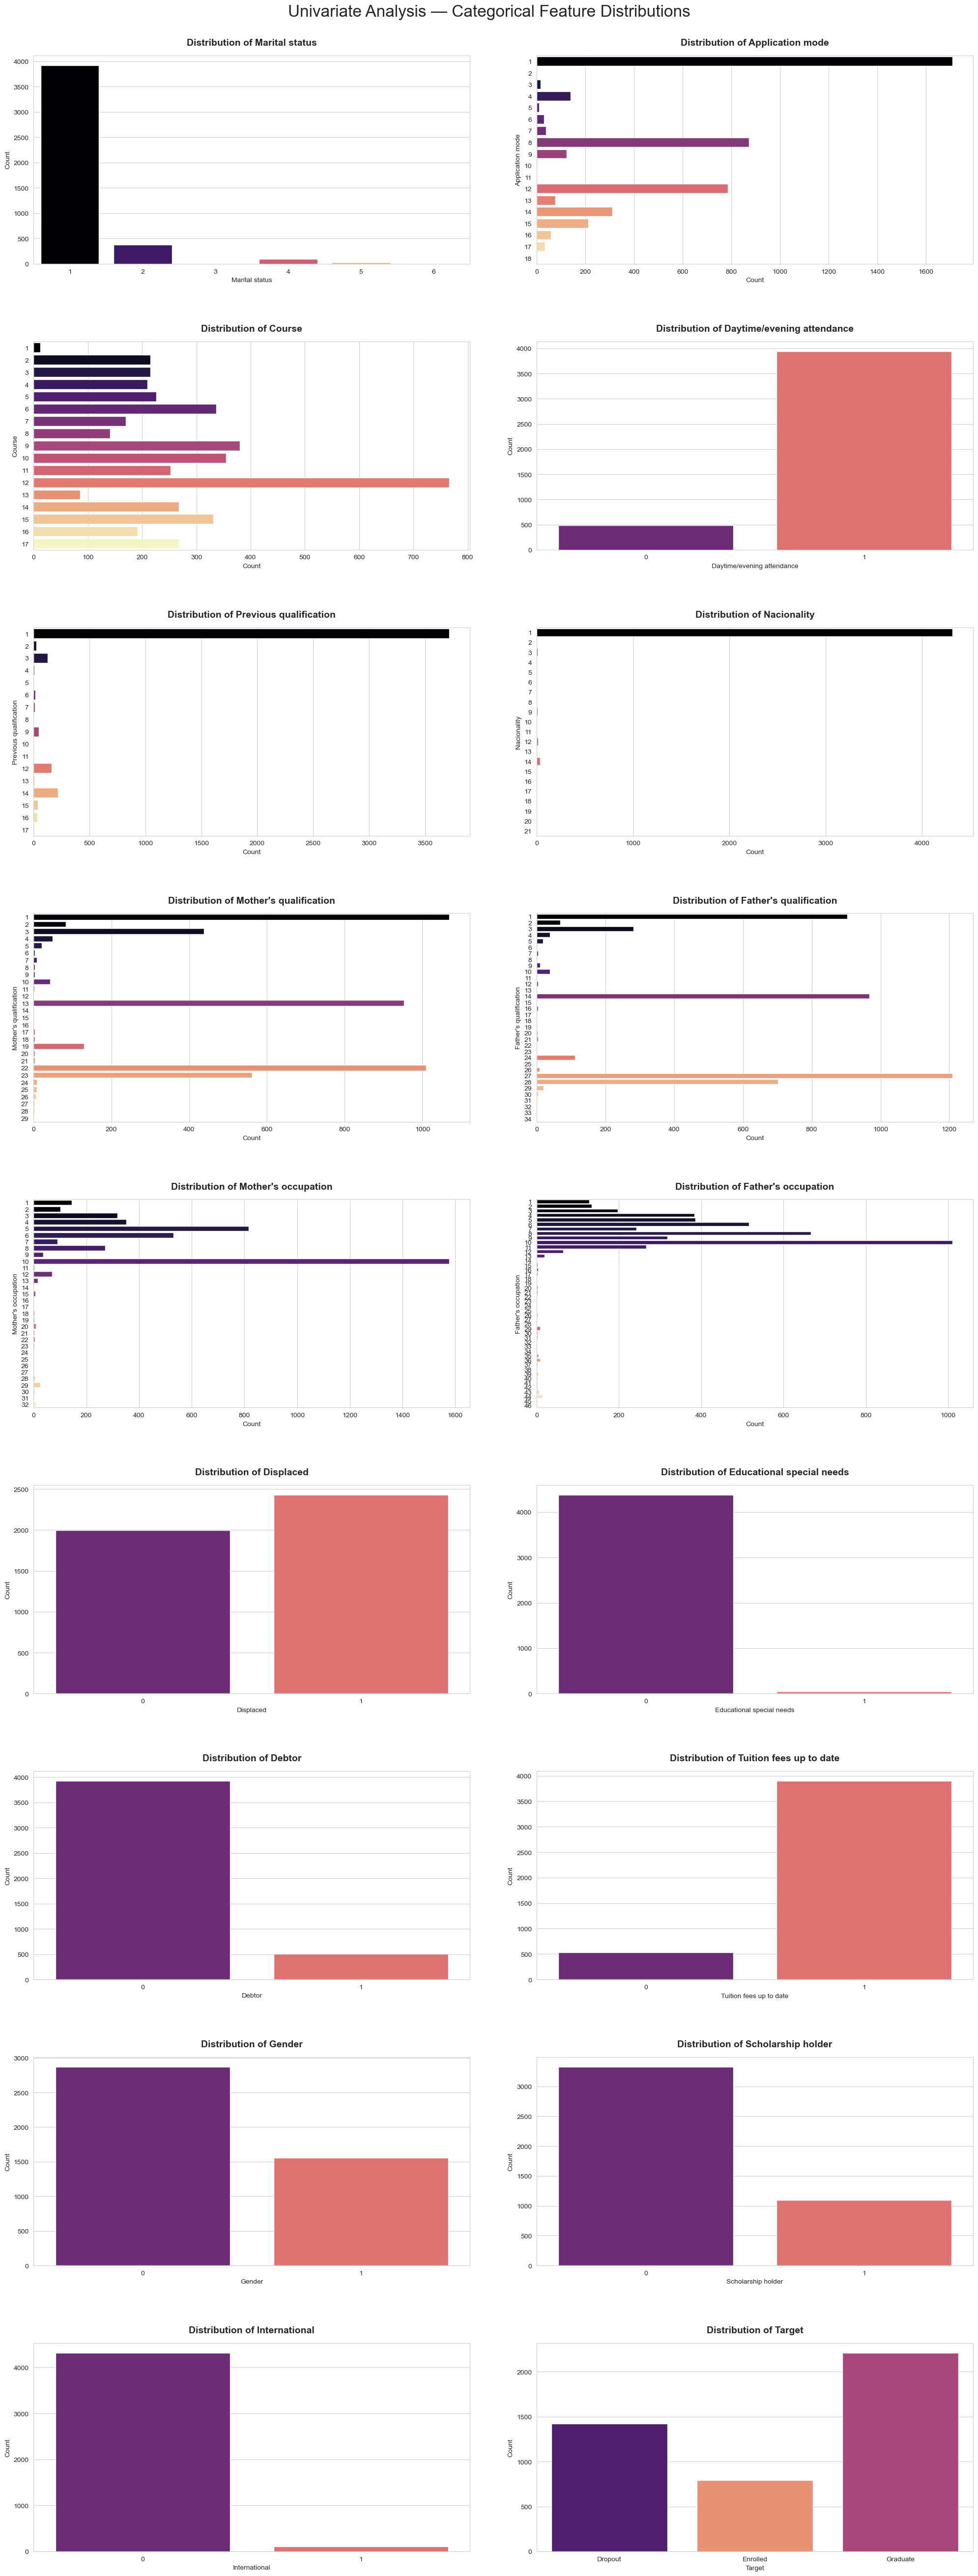

In [13]:
# Univariate Analysis: Categorical Features
# 1. Setup the figure grid
n_cols = 2
n_rows = (len(categorical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Sort by the ID/Value (1, 2, 3...) so the axis stays numerical
    order = df[col].value_counts().sort_index().index
    
    # 2. Conditional Logic for Plot Orientation
    if len(order) > 10:
        # HORIZONTAL: Better for many categories (Occupations, Qualifications)
        sns.countplot(data=df, y=col, ax=axes[i], order=order, 
                      hue=col, palette='magma', legend=False)
        axes[i].set_xlabel('Count')      # Count is on the bottom
        axes[i].set_ylabel(col)           # Feature name is on the left
    else:
        # VERTICAL: Better for simple categories (Gender, Target, Attendance)
        sns.countplot(data=df, x=col, ax=axes[i], order=order, 
                      hue=col, palette='magma', legend=False)
        axes[i].set_xlabel(col)           # Feature name is on the bottom
        axes[i].set_ylabel('Count')      # Count is on the left

    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=15)

# 3. Final layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.99], h_pad=6.0, w_pad=5.0)
plt.suptitle('Univariate Analysis — Categorical Feature Distributions', fontsize=24, y=1.00)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [14]:
barcharts_insights = {
    "1. Marital status": 
        """Observation: Extreme imbalance; the vast majority of students are single (category 1), with very low counts for married or divorced categories.
        Key Insight: Marital status is a nearly constant variable for this student population.
        Phase 3 Action: Collapse into a binary feature: 'is_single' (1) vs. 'other' (0) to prevent the model from learning noise from underrepresented categories.""",

    "2. Application mode": 
        """Observation: Multi-modal distribution with several high-frequency peaks (e.g., categories 1, 8, and 17).
        Key Insight: Students enter through diverse administrative channels, which may reflect different academic backgrounds or socio-economic quotas.
        Phase 3 Action: Apply Target Encoding to capture the historical dropout risk associated with specific entry paths without expanding the feature space excessively.""",

    "3. Course": 
        """Observation: High cardinality with significant variation in popularity. Some courses have 3-4x more students than others.
        Key Insight: Enrollment is not uniform across disciplines; certain departments (e.g., category 12) dominate the student body.
        Phase 3 Action: Group low-frequency courses into an 'Other_Courses' bucket or use Frequency Encoding to represent the 'size' of the department.""",

    "4. Daytime/evening attendance": 
        """Observation: Heavily skewed toward daytime attendance; evening students represent a small minority.
        Key Insight: The institution is primarily a daytime facility, which may impact the availability of support services for the evening minority.
        Phase 3 Action: Retain as a binary flag; investigate if evening attendance correlates with the higher-age 'Dropout' profile in bivariate analysis.""",

    "5. Previous qualification": 
        """Observation: Massive peak at the standard secondary education level, with very sparse data for other qualification types.
        Key Insight: Most students follow a traditional educational trajectory.
        Phase 3 Action: Binary encode as 'Traditional_Secondary' (1) vs. 'Advanced/Other' (0) to simplify the decision boundary.""",

    "6. Nationality": 
        """Observation: Near-zero variance; the overwhelming majority of students are of the primary nationality.
        Key Insight: The dataset lacks sufficient diversity in nationality to be a meaningful independent predictor for most models.
        Phase 3 Action: Candidate for removal (Feature Selection) or conversion to a simple 'is_native' binary flag.""",

    "7. Mother's/Father's qualification": 
        """Observation: Both features show similar multi-modal distributions with peaks in basic education levels.
        Key Insight: Reflects a consistent socio-economic background for the student body.
        Phase 3 Action: These are highly correlated; consider creating a 'Max_Parental_Education' feature to reduce redundancy.""",

    "8. Mother's/Father's occupation": 
        """Observation: Highly fragmented with many low-frequency categories.
        Key Insight: Professional background is the most diverse categorical domain in the dataset.
        Phase 3 Action: Use Target Encoding here, as standard One-Hot Encoding would create too many sparse columns (Curse of Dimensionality).""",

    "9. Displaced": 
        """Observation: Relatively balanced distribution compared to other features.
        Key Insight: A significant portion of the student body has moved from their home region to attend university.
        Phase 3 Action: Keep as a binary feature; it is a good proxy for student independence and external living costs.""",

    "10. Educational special needs": 
        """Observation: Extreme imbalance; the 'Yes' category is barely visible.
        Key Insight: Very few students in this sample require documented special education support.
        Phase 3 Action: Likely to be dropped during feature pruning due to near-zero variance.""",

    "11. Debtor": 
        """Observation: Heavily skewed toward 'No' (0), but the 'Yes' (1) group is large enough to be statistically relevant.
        Key Insight: Financial strain (debt) is a minority but significant state.
        Phase 3 Action: This is a high-priority feature. In Phase 3, ensure this binary flag is prioritized as a potential 'early warning' signal.""",

    "12. Tuition fees up to date": 
        """Observation: Majority have fees up to date, but a distinct minority does not.
        Key Insight: Direct indicator of financial standing and administrative compliance.
        Phase 3 Action: Cross-reference with 'Debtor' status to create a 'Financial_Risk_Score' (0-2).""",

    "13. Gender": 
        """Observation: Moderately balanced but shows a higher proportion of one gender (likely Female, based on dataset documentation).
        Key Insight: Gender is one of the few categorical features with enough variance to be a stable predictor.
        Phase 3 Action: Keep as a standard binary feature; check for gender-based performance gaps in Phase 4.""",

    "14. Scholarship holder": 
        """Observation: Approximately 1/3 of the students hold scholarships.
        Key Insight: Financial aid is a common but not universal factor in this population.
        Phase 3 Action: Retain as binary; scholarships often act as an incentive that reduces dropout risk.""",

    "15. International": 
        """Observation: Extreme imbalance; international students are a very small fraction of the total.
        Key Insight: Similar to Nationality, there is insufficient data to draw broad conclusions about international student success.
        Phase 3 Action: Candidate for removal to simplify the model.""",

    "16. Target (Target Variable)": 
        """Observation: Imbalanced distribution with 'Graduate' as the majority, followed by 'Dropout', and 'Enrolled' as the smallest class.
        Key Insight: The classification task is imbalanced, which will bias the model toward 'Graduate' predictions.
        Phase 3 Action: Use SMOTE (Synthetic Minority Over-sampling Technique) or class weighting in the model to balance the 'Dropout' and 'Enrolled' signals."""
}

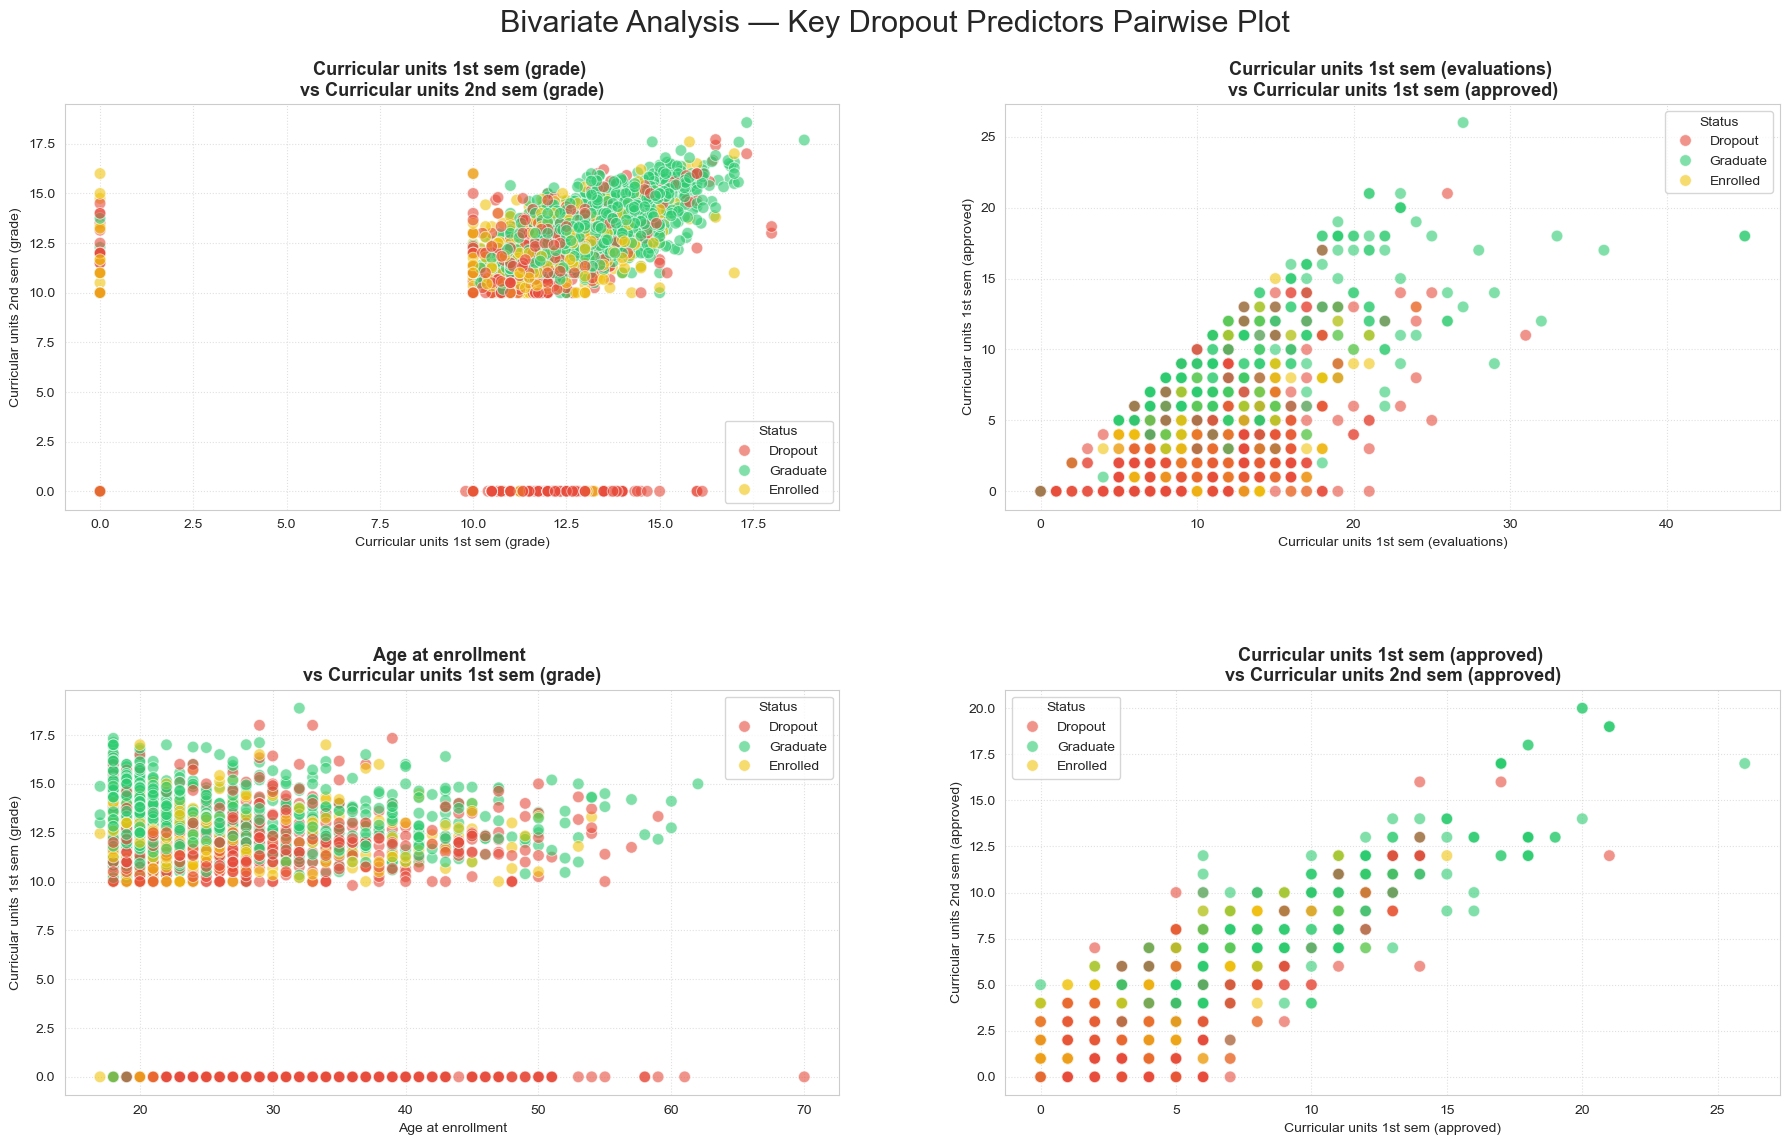

In [15]:
# 1. Predictive Pairs
analysis_pairs = [
    # Academic performance consistency (The strongest predictor)
    ('Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'),
    
    # Effort vs. Actual Success
    ('Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)'),
    
    # Age vs. 1st Semester Performance
    ('Age at enrollment', 'Curricular units 1st sem (grade)'),
    
    # Academic Progress/Retention
    ('Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)')
]

# 2. Setup the Plotting Grid
n_rows, n_cols = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

palette_colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f1c40f'}

for i, (x_col, y_col) in enumerate(analysis_pairs):
    try:
        sns.scatterplot(
            data=df, x=x_col, y=y_col, hue='Target', 
            ax=axes[i], alpha=0.6, s=70, 
            palette=palette_colors
        )
        axes[i].set_title(f'{x_col} \nvs {y_col}', fontsize=13, fontweight='bold')
        axes[i].legend(title='Status', loc='best')
        axes[i].grid(True, linestyle=':', alpha=0.6)
        
    except ValueError as e:
        axes[i].set_title(f"Error: Column not found", color='red')
        print(f"Skipping pair {x_col} vs {y_col}: {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=7.0, w_pad=8.0)
plt.suptitle('Bivariate Analysis — Key Dropout Predictors Pairwise Plot', fontsize=22, y=0.98)

plt.show()

In [16]:
analysis_insights = {
    "1. Academic Consistency": 
        """1. Curricular units 1st sem (grade) vs 2nd sem (grade)
        Observation: There is a strong, dense positive correlation between 1st and 2nd-semester grades for Graduates (green dots), forming a cluster between the 10 and 17.5 marks. However, Dropouts (red dots) are heavily concentrated at the 0.0 marks on both axes.
        Key Insight: Academic performance is consistent. If a student starts with a grade of 0 in the 1st semester, they almost never recover in the 2nd. This "Zero-Grade" signature is the most distinct visual separator for dropouts.
        Phase 3 Action: This confirms that grade is a high-priority feature. We might consider a feature that flags "Zero Performance" in either semester.""",

    "2. Engaged Failure": 
        """2. Curricular units 1st sem (evaluations) vs 1st sem (approved)
        Observation: This plot shows a "fan" shape. We see many Dropouts (red) who have a high number of evaluations (between 10 and 20) but zero approved units.
        Key Insight: This identifies "Engaged Failure." These students are actually taking the exams (evaluations) but failing to pass the units (approved). It proves that dropping out isn't always about "not showing up"; it's often about struggling with the difficulty of the material.
        Phase 3 Action: Creating a ratio of Approved / Evaluations would be a powerful feature to capture student efficiency.""",

    "3. Maturity Risk": 
        """3. Age at enrollment vs Curricular units 1st sem (grade)
        Observation: The green dots (Graduates) are heavily concentrated in the 18–25 age range. As the Age at enrollment increases (moving right toward 40–60), the proportion of red dots (Dropouts) significantly increases.
        Key Insight: There is a "Maturity Risk." While older students enter with varying grades, they are statistically more likely to drop out than their younger peers. This might be due to external responsibilities (work/family) that aren't in the data.
        Phase 3 Action: Age should be treated as a key demographic risk factor. To help the model, we could "bin" age into groups (e.g., 18-25, 26-35, 36+).""",

    "4. Academic Momentum": 
        """4. Curricular units 1st sem (approved) vs 2nd sem (approved)
        Observation: This is the "Progress" map. Graduates (green) are almost entirely in the top-right corner, passing 5 or more units per semester. Dropouts (red) are clustered in the bottom-left, passing 0 to 2 units.
        Key Insight: Momentum is the best predictor. The difference between passing 0 units and passing 5 units is the clearest "line in the sand" for your model. There is very little overlap between the colors here compared to the other graphs.
        Phase 3 Action: This is likely the "Star" feature. In Phase 3, ensure that the number of approved units is weighted heavily, as it shows the most direct path to graduation."""
}

for key, value in analysis_insights.items():
    print(value)
    print("-" * 30)

1. Curricular units 1st sem (grade) vs 2nd sem (grade)
        Observation: There is a strong, dense positive correlation between 1st and 2nd-semester grades for Graduates (green dots), forming a cluster between the 10 and 17.5 marks. However, Dropouts (red dots) are heavily concentrated at the 0.0 marks on both axes.
        Key Insight: Academic performance is consistent. If a student starts with a grade of 0 in the 1st semester, they almost never recover in the 2nd. This "Zero-Grade" signature is the most distinct visual separator for dropouts.
        Phase 3 Action: This confirms that grade is a high-priority feature. We might consider a feature that flags "Zero Performance" in either semester.
------------------------------
2. Curricular units 1st sem (evaluations) vs 1st sem (approved)
        Observation: This plot shows a "fan" shape. We see many Dropouts (red) who have a high number of evaluations (between 10 and 20) but zero approved units.
        Key Insight: This identifi

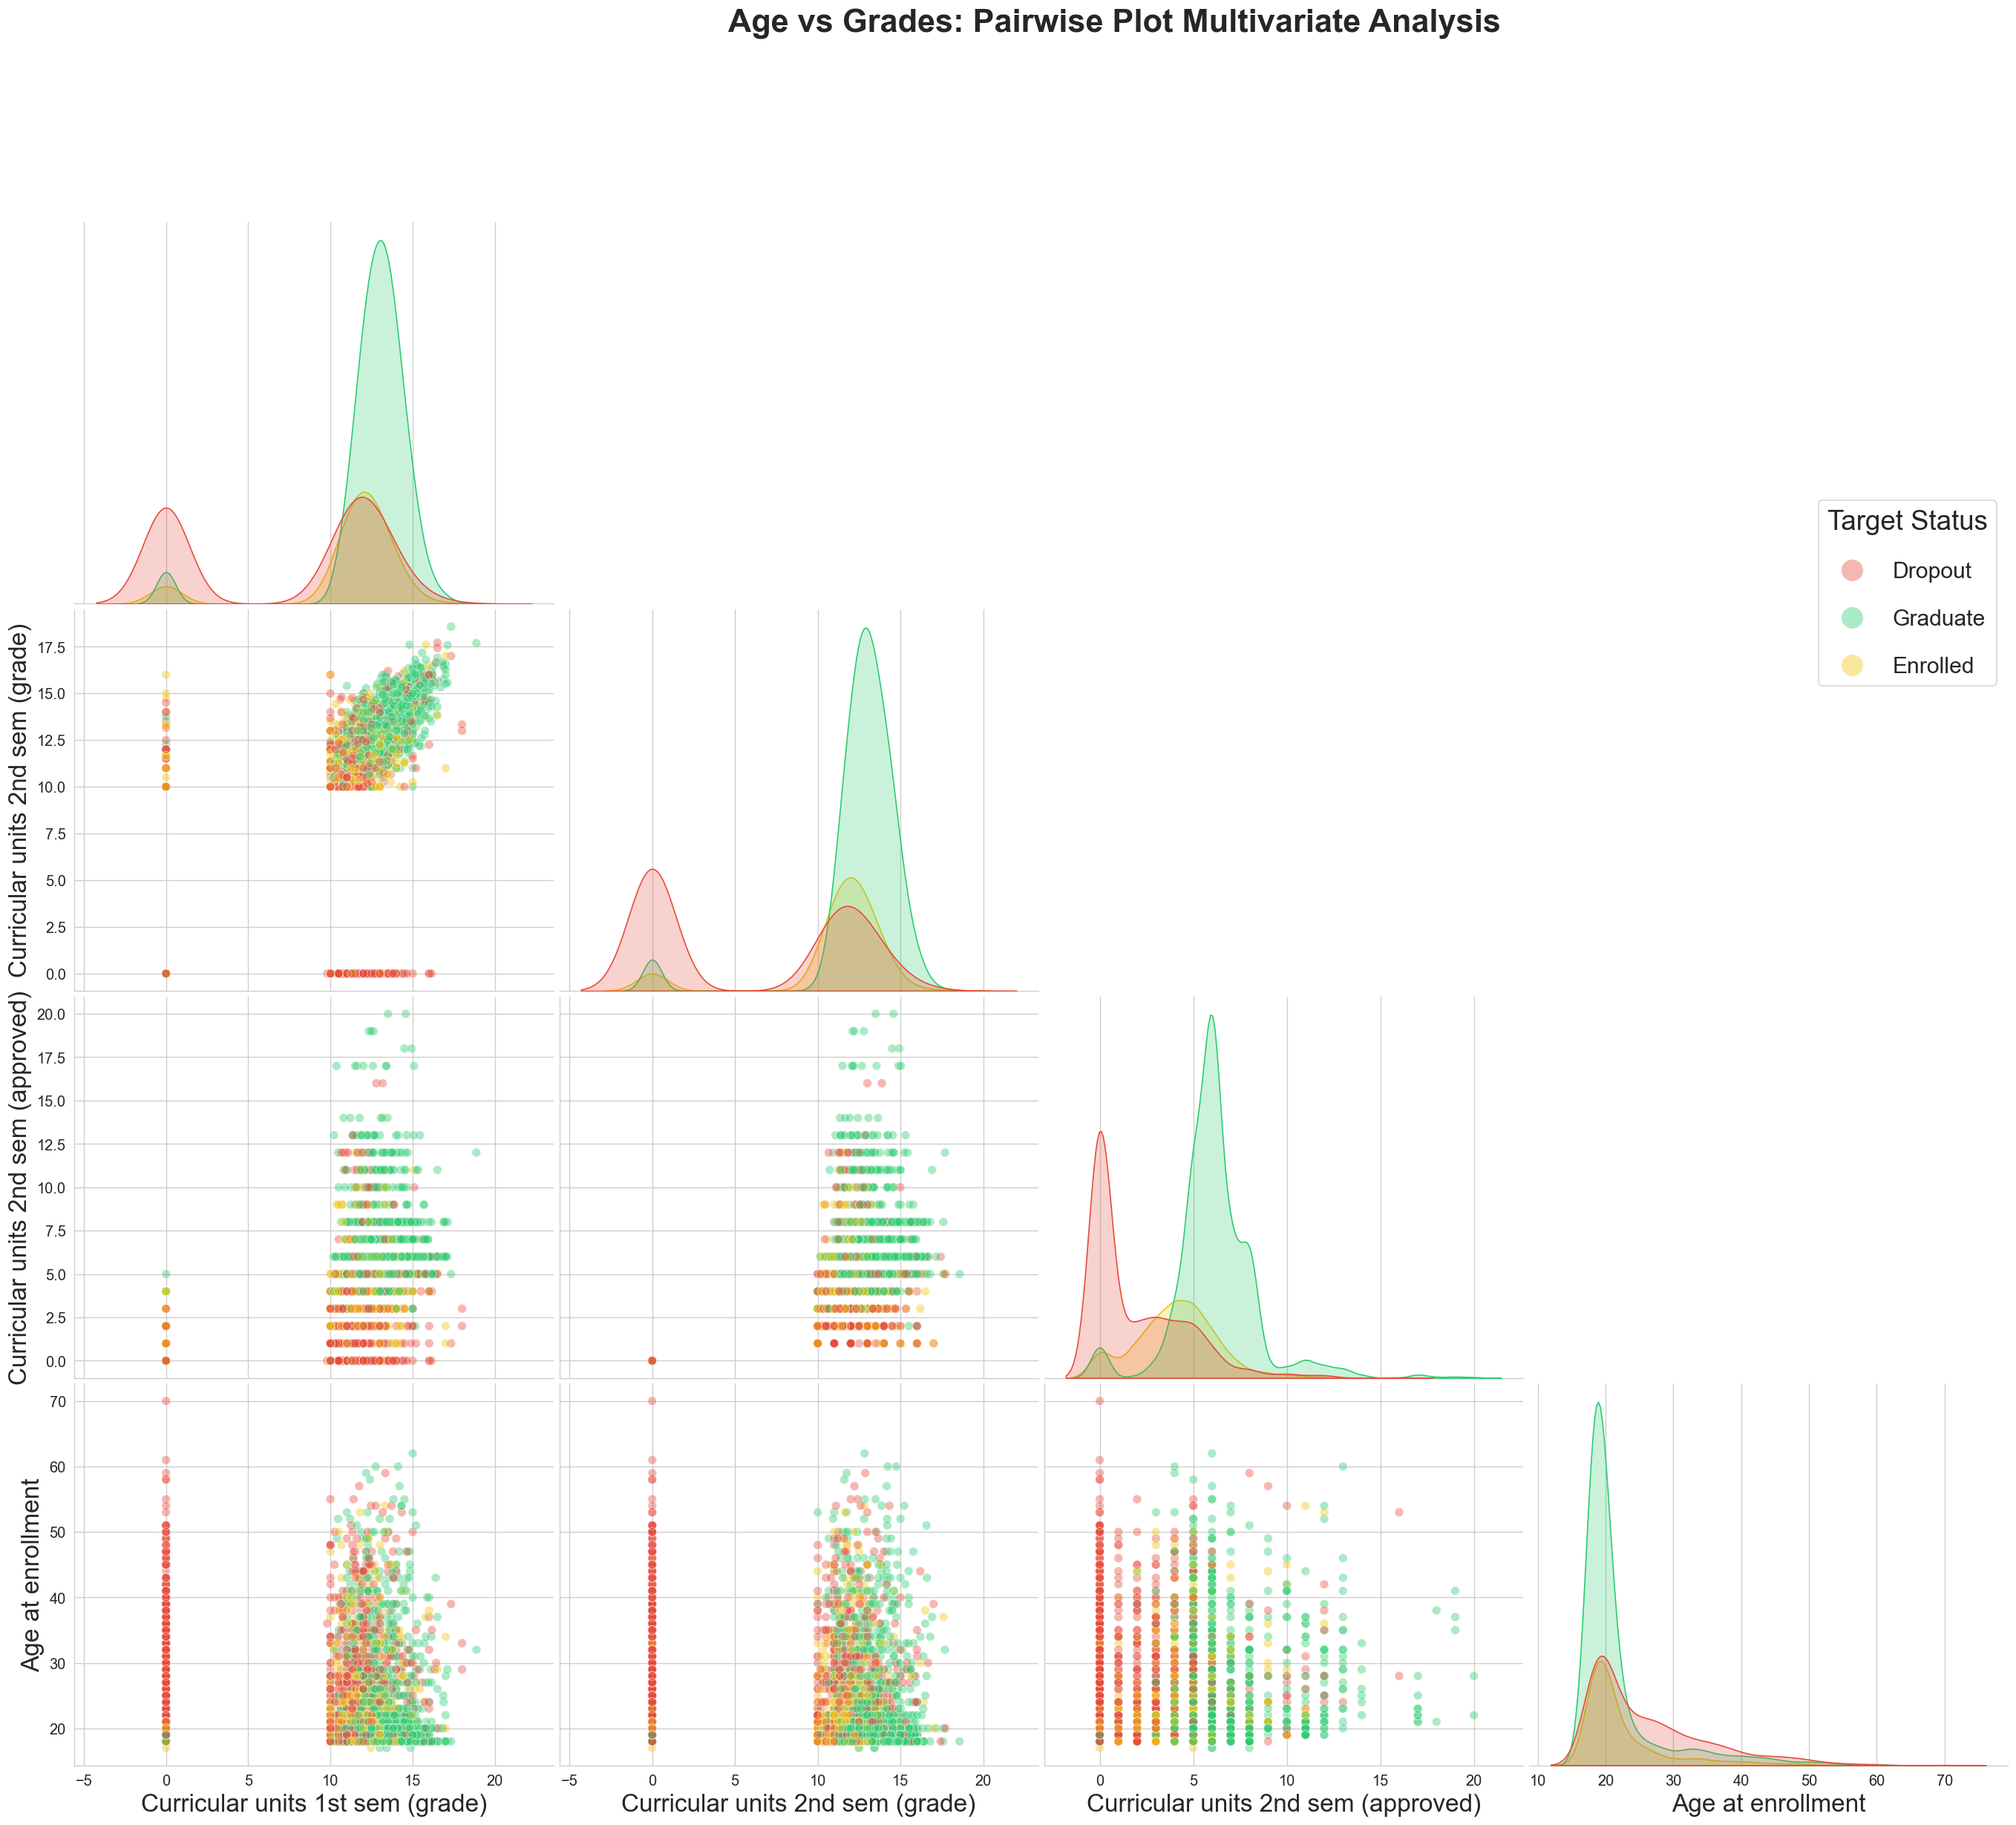

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your standard color mapping
target_colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f1c40f'}

# 1. Set global sharpness
plt.rcParams['figure.dpi'] = 120

key_features = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Age at enrollment',
    'Target'
]

# 2. Plotting - Palette is now set to your custom dictionary
g = sns.pairplot(
    df[key_features], 
    hue='Target', 
    corner=True, 
    palette=target_colors,  # <--- Custom colors applied here
    diag_kind='kde',
    height=5,      
    aspect=1.2,
    plot_kws={'alpha': 0.4, 's': 50}
)

# 3. The Legend 
sns.move_legend(
    g, 
    loc="upper right", 
    bbox_to_anchor=(0.9, 0.75), 
    title="Target Status",
    title_fontsize=22, 
    fontsize=18, 
    labelspacing=1.2,
    markerscale=2.5,           
    frameon=True               
)

# 4. Make Axis Titles bigger
for ax in g.axes.flatten():
    if ax is not None:
        # Set both size and weight for better readability
        ax.xaxis.get_label().set_fontsize(20)
        ax.yaxis.get_label().set_fontsize(20)
        # Optional: make the tick marks (numbers) slightly larger too
        ax.tick_params(axis='both', which='major', labelsize=12)

# 5. Super Title
g.fig.suptitle('Age vs Grades: Pairwise Plot Multivariate Analysis', 
               fontsize=26, fontweight='bold', y=1.02)

# 6. Final Adjustment
plt.subplots_adjust(top=0.9, right=0.9) 
plt.show()

In [18]:
multivariate_insights = {
    "1. The 'Zero-Grade' Dropout Signature": 
        """1. The 'Zero-Grade' Dropout Signature
        Observation: In the 1st vs 2nd sem (grade) plot, there is a massive cluster of Dropouts (red) exactly at the (0,0) mark. This pattern is mirrored in the Multivariate Pairplot, where the density peaks (KDE) for Dropouts are heavily skewed toward zero.
        Key Insight: A total academic failure in the first semester is almost impossible to recover from. This 'Zero-Grade' signature is the single most statistically significant visual indicator of an impending dropout.
        Phase 3 Action: Engineer a boolean flag called is_zero_performer. This will allow the model to immediately categorize these 'clear-cut' cases without getting distracted by other variables.""",

    "2. The Efficiency Gap": 
        """2. The Efficiency Gap (Evaluations vs. Approved)
        Observation: The 1st sem (evaluations) vs (approved) scatter plot shows a 'fan' distribution. Many Dropouts have a high number of evaluations (15–20) but zero approved units.
        Key Insight: We have identified a group of 'Struggling but Engaged' students. They are physically present and taking exams, but they aren't passing. This proves that dropout risk isn't just about 'not showing up'; it's about a lack of academic competency or preparation.
        Phase 3 Action: Create an Efficiency_Ratio feature (Approved / Evaluations). A low ratio identifies students who are working hard but failing, which is a different risk profile than those who simply don't attend.""",

    "3. Academic Momentum": 
        """3. Academic Momentum as the 'Star Predictor'
        Observation: In both the Bivariate (Approved vs. Approved) and Multivariate plots, the Curricular units 2nd sem (approved) variable shows the cleanest separation between classes. Graduates are almost entirely in the 'high approval' zone (6+ units).
        Key Insight: Momentum is everything. If a student passes their full load in the second semester, their probability of graduating is nearly 100%. The 'Enrolled' (blue) students sit in the middle, showing they are currently at a 'pivot point' in their academic journey.
        Phase 3 Action: During Feature Selection, prioritize Approved Units over Grades. The model will find it easier to learn a 'count-based' rule than a 'score-based' one.""",

    "4. The Maturity Risk Factor": 
        """4. The Maturity Risk Factor (Age)
        Observation: Across all plots involving Age at enrollment, the density of Dropouts increases significantly as age moves toward the 30–50 range. Younger students (18–22) are the primary occupants of the "Graduate" clusters.
        Key Insight: 'Mature Students' are a high-risk demographic. This suggests that external life pressures (employment, family, or long gaps in education) create volatility that younger, traditional students don't face.
        Phase 3 Action: Bin the Age column into categorical groups like Traditional (18-24), Adult Learner (25-35), and Senior (35+). This helps the model treat age as a non-linear risk factor rather than just a simple number."""
}

for section, text in multivariate_insights.items():
    print(text)
    print("-" * 50)

1. The 'Zero-Grade' Dropout Signature
        Observation: In the 1st vs 2nd sem (grade) plot, there is a massive cluster of Dropouts (red) exactly at the (0,0) mark. This pattern is mirrored in the Multivariate Pairplot, where the density peaks (KDE) for Dropouts are heavily skewed toward zero.
        Key Insight: A total academic failure in the first semester is almost impossible to recover from. This 'Zero-Grade' signature is the single most statistically significant visual indicator of an impending dropout.
        Phase 3 Action: Engineer a boolean flag called is_zero_performer. This will allow the model to immediately categorize these 'clear-cut' cases without getting distracted by other variables.
--------------------------------------------------
2. The Efficiency Gap (Evaluations vs. Approved)
        Observation: The 1st sem (evaluations) vs (approved) scatter plot shows a 'fan' distribution. Many Dropouts have a high number of evaluations (15–20) but zero approved units.
  

NameError: name 'ScalarFormatter' is not defined

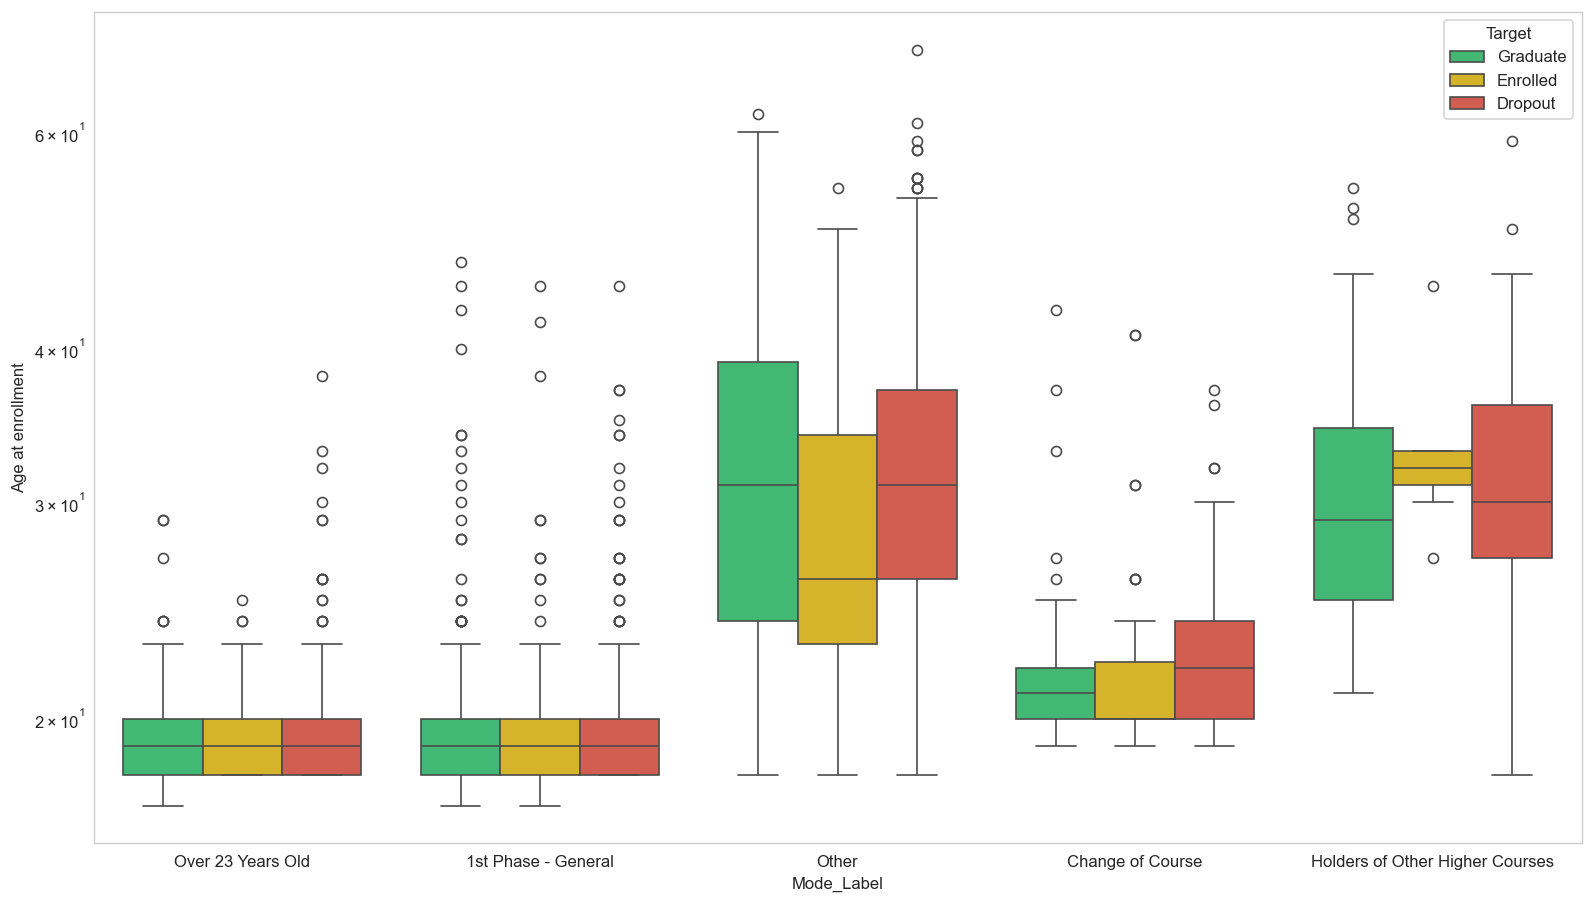

In [19]:
# Multivariate Analysis: Age vs. Application Mode vs. Target Visualization by Boxplot

target_colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f1c40f'}

# 1. Mapping and Filtering
mode_labels = {
    1: "1st Phase - General", 2: "Ordinance n. 612/93", 3: "1st Phase - Special (Ads)",
    4: "Holders of Other Higher Courses", 5: "1st Phase - Special Condition",
    7: "Holders of Other Higher Courses", 8: "Over 23 Years Old", 10: "Transfer",
    15: "Change of Course", 16: "Technical Course Holder", 17: "2nd Phase - General",
    18: "3rd Phase - General", 26: "712 Certificate", 
    27: "Holders of Other Higher Courses (Special)", 39: "Over 23 Years Old (Special)",
    42: "Transfer (Special)", 43: "International Student", 44: "Technological Specialization"
}

df['Mode_Label'] = df['Application mode'].map(mode_labels).fillna('Other')
top_modes = df['Application mode'].value_counts().head(6).index
df_plot = df[df['Application mode'].isin(top_modes)].copy()

# 2. Create the Visualization
plt.figure(figsize=(16, 9), dpi=120) 

sns.boxplot(
    data=df_plot, 
    x='Mode_Label', 
    y='Age at enrollment', 
    hue='Target', 
    palette=target_colors, 
    hue_order=['Graduate', 'Enrolled', 'Dropout'] 
)

# 3. Log Scale Configuration
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.yticks([18, 20, 25, 30, 40, 50, 60, 70])

# 4. Styling and Labels 
plt.title('Impact of Age and Entry Path on Student Success', 
          fontsize=20, fontweight='bold', pad=20)

plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('Entry Application Mode', fontsize=14, fontweight='bold')
plt.ylabel('Age at Enrollment (Years)', fontsize=14, fontweight='bold')

# 5. Legend Fix 
plt.legend(title='Outcome', 
           title_fontsize=16, 
           fontsize=14, 
           bbox_to_anchor=(1.02, 1), 
           loc='upper left',
           frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
bivariate_age_path_insights = {
    "1. Age-Entry Nonlinearity Analysis": {
        "Observation": "In '1st Phase - General' entry, median ages are consistent (~19) across all targets, yet high-age outliers (50+) successfully graduate.",
        "Technical Insight": "Age is a non-linear predictor. Success in traditional entry phases is not strictly capped by age, whereas non-traditional paths show higher age-based sensitivity.",
        "Action": "Engineer 'is_mature_entry' using a logical intersection of Age > 25 and specific Application Modes (8, 39) to isolate high-risk mature profiles without biasing against resilient older students."
    },
    "2. Entry Mode Variance & Stability": {
        "Observation": "Standardized entry paths demonstrate a wider variance in successful age distributions compared to specialized 'Over 23' paths.",
        "Technical Insight": "Traditional academic pathways appear more structurally 'forgiving' of age variance than vocational or specialized entry channels.",
        "Action": "Apply a combination of binary flagging for standard secondary qualifications and identified top-tier modes for frequency-based filtering to reduce noise in the feature space."
    },
    "3. Late-Stage Academic Reorientation Risk": {
        "Observation": "The 'Change of Course' (Mode 15) category shows a significantly larger Dropout IQR and a higher median age for attrition compared to Graduation.",
        "Technical Insight": "Academic 'course correction' in the late 20s correlates with a higher probability of attrition compared to early-stage major changes.",
        "Action": "Develop a 'late_switcher' interaction feature (Age > 22 & Application Mode 15) to specifically capture the risk profile associated with late-career academic transitions."
    }
}

print("BIVARIATE ANALYSIS SUMMARY: AGE & ENTRY PATH DYNAMICS")
print("-" * 65)
for category, content in bivariate_age_path_insights.items():
    print(f"\n{category.upper()}")
    for key, value in content.items():
        print(f"  > {key}: {value}")

BIVARIATE ANALYSIS SUMMARY: AGE & ENTRY PATH DYNAMICS
-----------------------------------------------------------------

1. AGE-ENTRY NONLINEARITY ANALYSIS
  > Observation: In '1st Phase - General' entry, median ages are consistent (~19) across all targets, yet high-age outliers (50+) successfully graduate.
  > Technical Insight: Age is a non-linear predictor. Success in traditional entry phases is not strictly capped by age, whereas non-traditional paths show higher age-based sensitivity.
  > Action: Engineer 'is_mature_entry' using a logical intersection of Age > 25 and specific Application Modes (8, 39) to isolate high-risk mature profiles without biasing against resilient older students.

2. ENTRY MODE VARIANCE & STABILITY
  > Observation: Standardized entry paths demonstrate a wider variance in successful age distributions compared to specialized 'Over 23' paths.
  > Technical Insight: Traditional academic pathways appear more structurally 'forgiving' of age variance than vocation

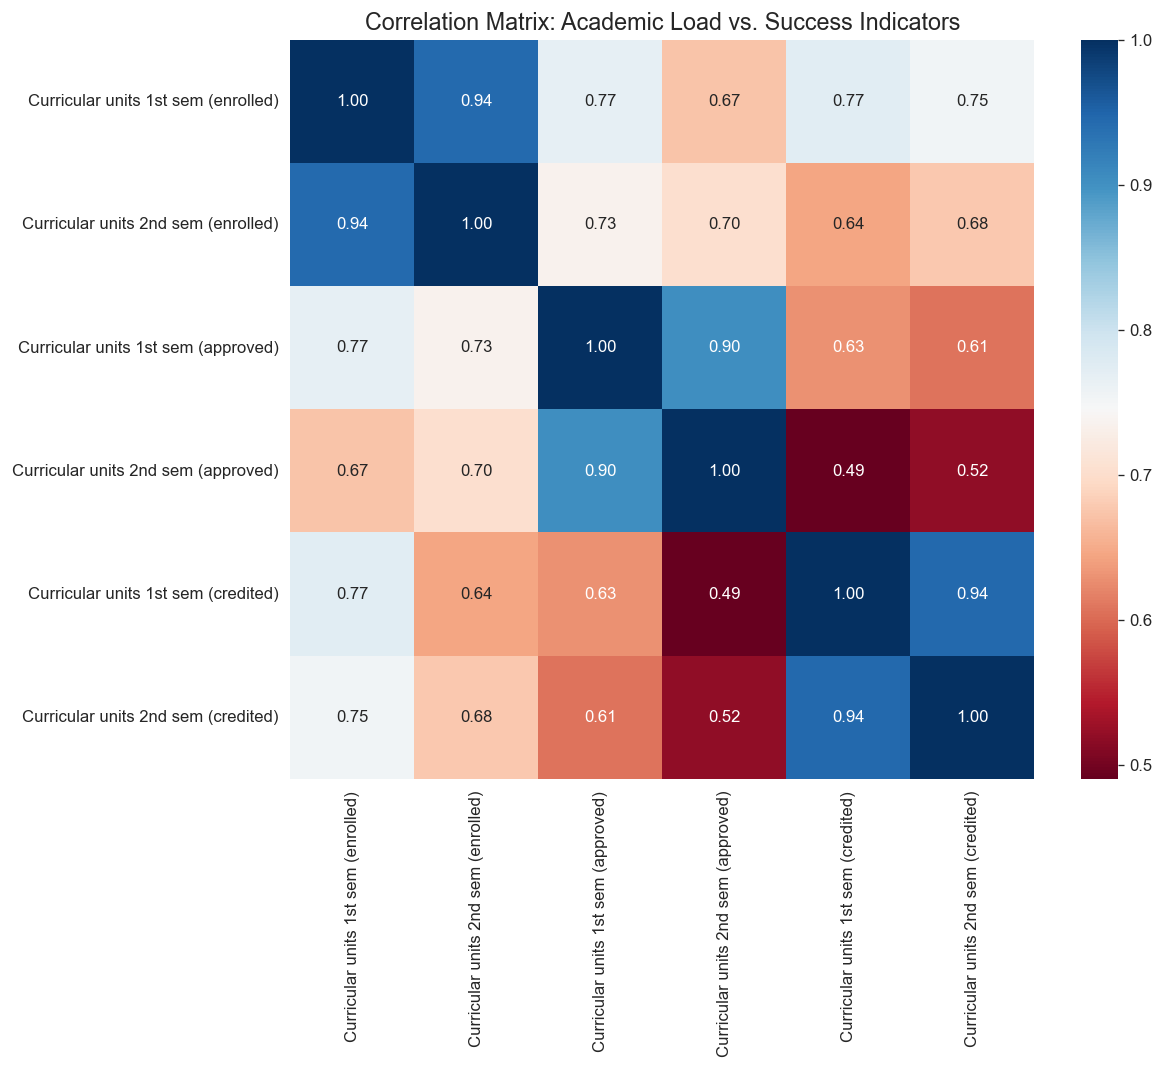

In [ ]:
# Correlation Matrix: Academic Load vs. Success Indicators by Heatmap 
admin_cols = [
    'Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[admin_cols].corr(), annot=True, cmap='RdBu', fmt='.2f')

plt.title('Correlation Matrix: Academic Load vs. Success Indicators', fontsize=14)
plt.show()

C:\Users\hanaa\AppData\Local\Temp\ipykernel_17168\1457007250.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, ax=axes[i], palette=colors)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_17168\1457007250.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, ax=axes[i], palette=colors)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_17168\1457007250.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, ax=axes[i], palette=colors)


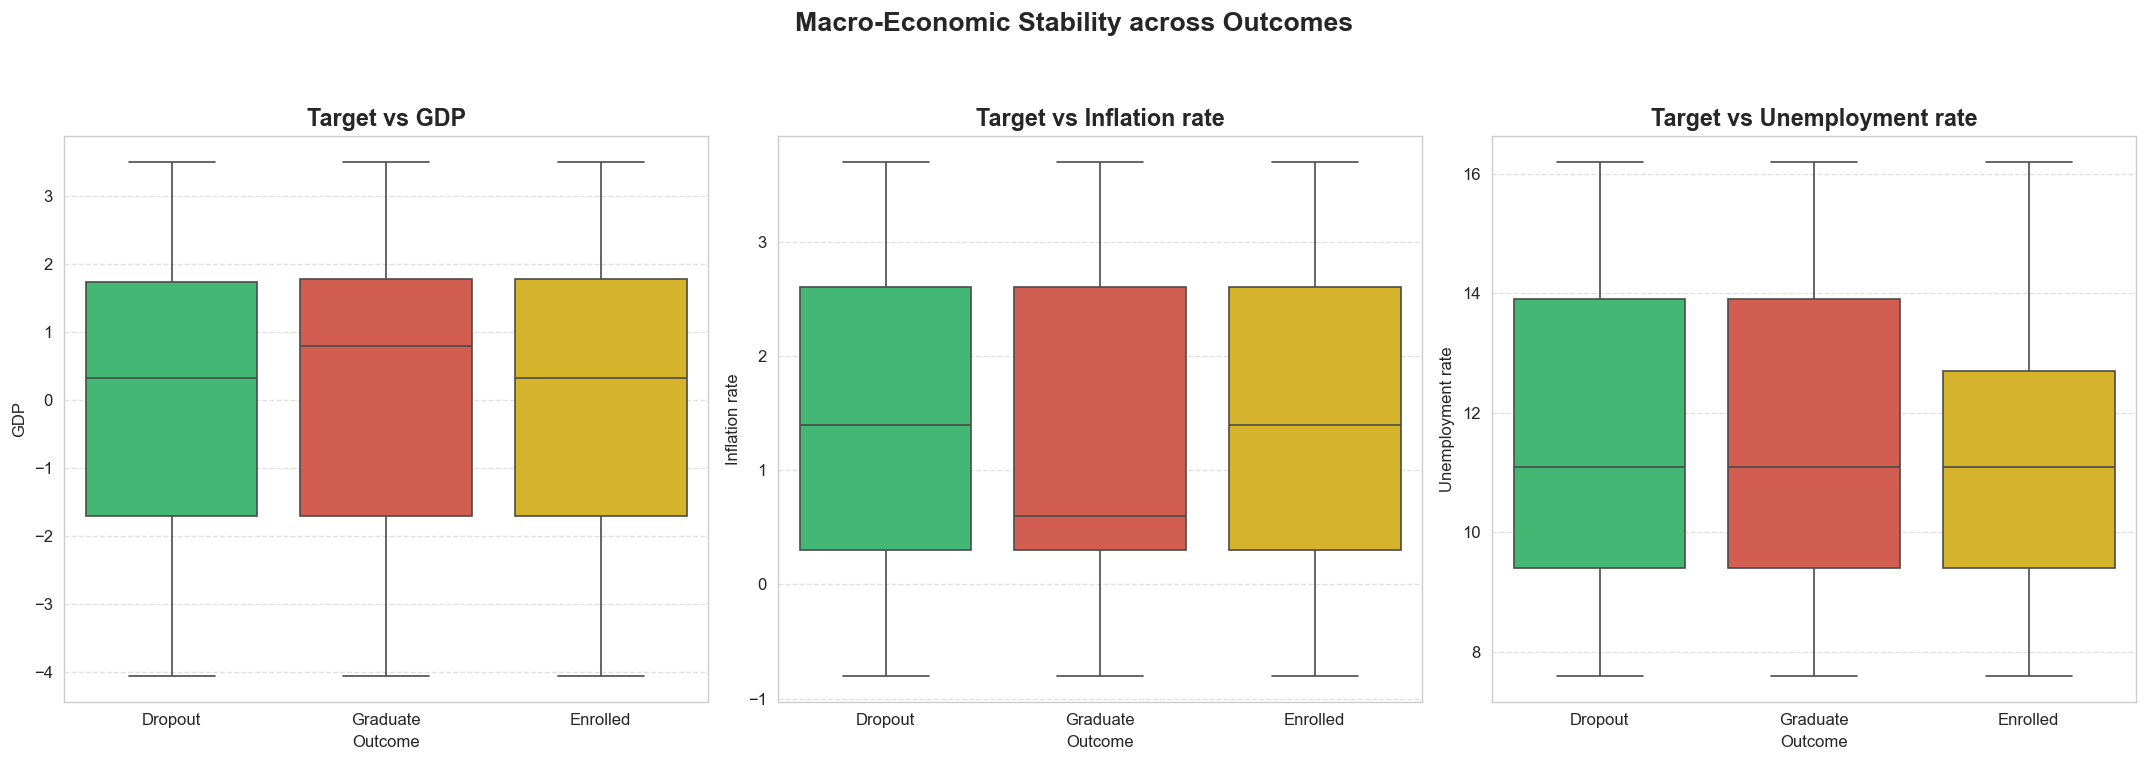

--- Mean Macro-Economic Indicators by Target ---
               GDP  Inflation rate  Unemployment rate
Target                                               
Dropout  -0.150859        1.283955          11.616397
Enrolled  0.053287        1.211713          11.272544
Graduate  0.081833        1.197918          11.639339


In [ ]:
# Features to check
macro_features = ['GDP', 'Inflation rate', 'Unemployment rate']

# 1. Visual Proof: Box Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2ecc71', '#e74c3c', '#f1c40f']

for i, col in enumerate(macro_features):
    sns.boxplot(data=df, x='Target', y=col, ax=axes[i], palette=colors)
    axes[i].set_title(f'Target vs {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Macro-Economic Stability across Outcomes', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 2. Statistical Proof: Grouped Means
print("--- Mean Macro-Economic Indicators by Target ---")
print(df.groupby('Target')[macro_features].mean())

In [ ]:
multivariate_visual_insights = {
    "1. Administrative Redundancy (Heatmap)": 
        """Multivariate Analysis: Correlation Heatmap of Academic Load
        Observation: We see a near-perfect positive correlation (0.94) between 1st and 2nd semester 'Enrolled' units and 'Credited' units.
        Key Insight: The administrative load is a 'Mirror' variable. Students rarely change their credit status or enrollment intensity mid-year, meaning the 2nd semester columns provide almost no 'new' information to the model.
        Phase 3 Action: Drop 'Curricular units 2nd sem (enrolled)' and 'Curricular units 2nd sem (credited)' to eliminate multicollinearity and simplify the feature space.""",

    "2. The Efficiency Gap (Heatmap)": 
        """Multivariate Analysis: Correlation Heatmap of Performance vs. Load
        Observation: The correlation between 'Enrolled' units (administrative load) and 'Approved' units (actual success) is only ~0.70.
        Key Insight: This 0.30 'Gap' identifies students who are 'Engaged but Failing.' They are attending and enrolled in a full load but are unable to convert that effort into passing grades.
        Phase 3 Action: Create an 'Academic_Efficiency' ratio (Approved / Evaluations) for both semesters to capture this competency gap mathematically.""",

    "3. Macro-Economic Independence (Triple Box Plot)":
        """Multivariate Analysis: Target vs. GDP, Inflation, and Unemployment
        Observation: The median and interquartile ranges (IQR) for GDP, Inflation, and Unemployment are almost identical across 'Dropout', 'Graduate', and 'Enrolled' categories.
        Key Insight: Macro-economic factors are 'Global' variables that lack the granularity to predict individual student success. The overlapping distributions prove these features offer no discriminative power.
        Phase 3 Action: Drop 'GDP', 'Inflation rate', and 'Unemployment rate' to prevent the model from finding noise-based patterns (overfitting) in the economy."""
}


print("SPECIFIC MULTIVARIATE INSIGHTS)\n" + "-"*60)
for key, value in multivariate_visual_insights.items():
    print(f"\n {key}")
    print(value)
    print("\n" + "-"*60)

SPECIFIC MULTIVARIATE INSIGHTS)
------------------------------------------------------------

 1. Administrative Redundancy (Heatmap)
Multivariate Analysis: Correlation Heatmap of Academic Load
        Observation: We see a near-perfect positive correlation (0.94) between 1st and 2nd semester 'Enrolled' units and 'Credited' units.
        Key Insight: The administrative load is a 'Mirror' variable. Students rarely change their credit status or enrollment intensity mid-year, meaning the 2nd semester columns provide almost no 'new' information to the model.
        Phase 3 Action: Drop 'Curricular units 2nd sem (enrolled)' and 'Curricular units 2nd sem (credited)' to eliminate multicollinearity and simplify the feature space.

------------------------------------------------------------

 2. The Efficiency Gap (Heatmap)
Multivariate Analysis: Correlation Heatmap of Performance vs. Load
        Observation: The correlation between 'Enrolled' units (administrative load) and 'Approved' unit

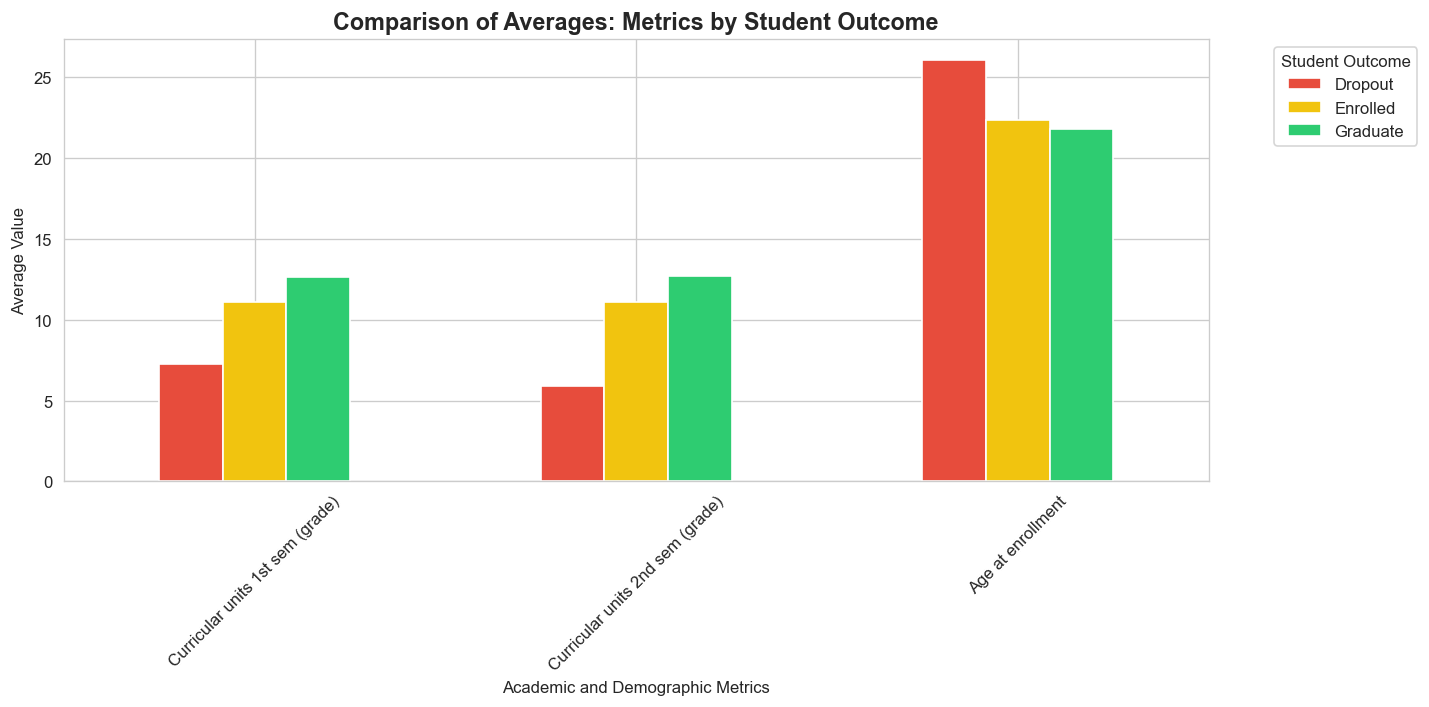

In [ ]:
# Transpose the summary so Metrics are on X-axis and Target is the Legend
grouped_summary.T.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#f1c40f', '#2ecc71'])

plt.title('Comparison of Averages: Metrics by Student Outcome', fontsize=14, fontweight='bold')
plt.ylabel('Average Value')
plt.xlabel('Academic and Demographic Metrics')
plt.xticks(rotation=45)
plt.legend(title='Student Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
bivariate_group_insights = {
    "1. The Performance Decay Factor": 
        """Bivariate Analysis: Comparison of Averages by Student Outcome
        Observation: While Graduates and Enrolled students maintain stable grades between semesters, Dropouts show a significant 'Performance Decay,' with averages dropping from 7.25 to 5.89.
        Key Insight: A falling grade trend is a massive red flag. Most dropouts don't just 'fail'—they actively get worse as the academic year progresses.
        Phase 3 Action: Create a 'Semester Grade Delta' feature (2nd Sem - 1st Sem). A negative value here will be a top-tier predictor for the model.""",

    "2. The 10-Point Safety Line": 
        """Bivariate Analysis: Comparison of Averages by Student Outcome
        Observation: Graduates (12.6) and Enrolled (11.1) students both sit comfortably above the 10-point passing threshold on average, whereas Dropouts are well below it (~6.5 avg).
        Key Insight: The 10-point mark acts as a 'Safety Line.' Once a student's average across both semesters dips below 10, the statistical probability of them being a 'Graduate' vanishes.
        Phase 3 Action: Consider creating a binary feature 'Below_Passing_Threshold' (Mean Grade < 10) to help the model quickly categorize these high-risk students.""",

    "3. Mature Student Risk Profile": 
        """Bivariate Analysis: Comparison of Averages by Student Outcome
        Observation: The average Age at enrollment for Dropouts (26.1) is nearly 20% higher than for Graduates (21.8).
        Key Insight: Higher age correlates with higher risk. This confirms our scatter plot finding that non-traditional students may require different intervention strategies than younger students.
        Phase 3 Action: Use Age as a key weight in the model. During preparation, ensure that outliers in the age column (e.g., students aged 60+) are handled so they don't skew the 'average' risk too much."""
}

# Loop to print everything neatly
for key, value in bivariate_group_insights.items():
    print(f"--- {key} ---")
    print(value)
    print("\n" + "="*50 + "\n")

--- 1. The Performance Decay Factor ---
Bivariate Analysis: Comparison of Averages by Student Outcome
        Observation: While Graduates and Enrolled students maintain stable grades between semesters, Dropouts show a significant 'Performance Decay,' with averages dropping from 7.25 to 5.89.
        Key Insight: A falling grade trend is a massive red flag. Most dropouts don't just 'fail'—they actively get worse as the academic year progresses.
        Phase 3 Action: Create a 'Semester Grade Delta' feature (2nd Sem - 1st Sem). A negative value here will be a top-tier predictor for the model.


--- 2. The 10-Point Safety Line ---
Bivariate Analysis: Comparison of Averages by Student Outcome
        Observation: Graduates (12.6) and Enrolled (11.1) students both sit comfortably above the 10-point passing threshold on average, whereas Dropouts are well below it (~6.5 avg).
        Key Insight: The 10-point mark acts as a 'Safety Line.' Once a student's average across both semesters dips 

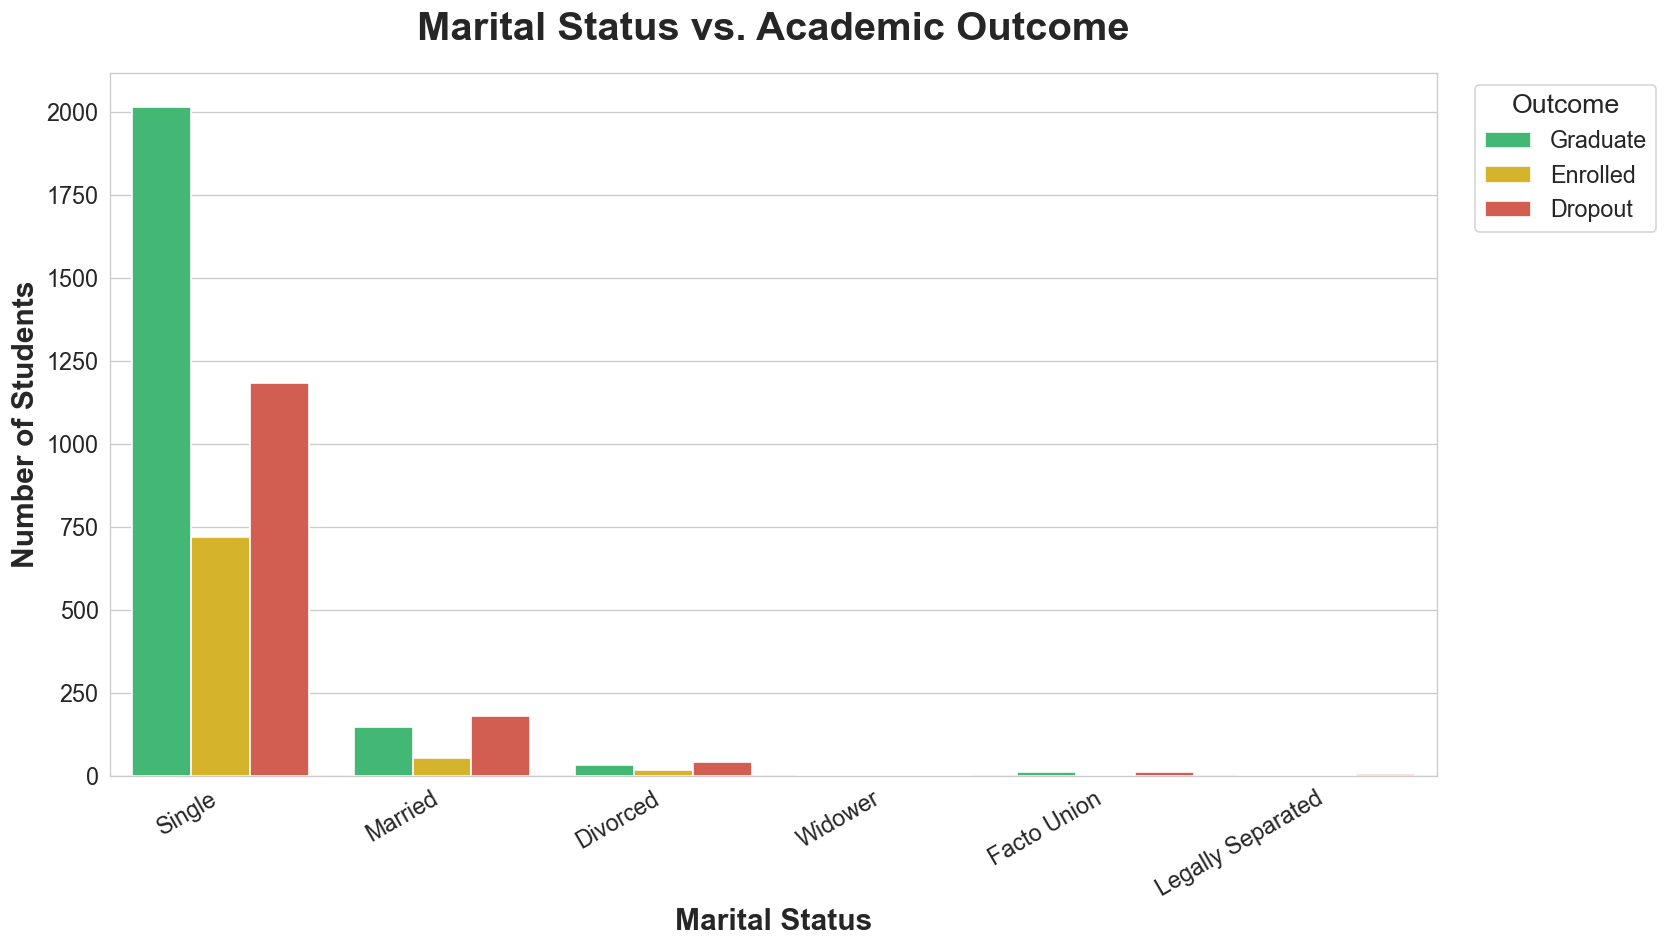

In [ ]:
target_colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f1c40f'}

# 1. Set global sharpness
plt.rcParams['figure.dpi'] = 120

# 2. Mapping
marital_status_map = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
}

df['Marital_Status_Label'] = df['Marital status'].map(marital_status_map)

# 3. Plotting
plt.figure(figsize=(14, 8))

sns.countplot(
    data=df, 
    x='Marital_Status_Label', 
    hue='Target', 
    palette=target_colors,  
    hue_order=['Graduate', 'Enrolled', 'Dropout'] 
)

# 4. Styling and Labels 
plt.title('Marital Status vs. Academic Outcome', fontsize=24, fontweight='bold', pad=20)

plt.xlabel('Marital Status', fontsize=18, fontweight='bold')
plt.ylabel('Number of Students', fontsize=18, fontweight='bold')

plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

# 5. Legend Fix
plt.legend(
    title='Outcome', 
    title_fontsize=16, 
    fontsize=14, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.show()

In [ ]:
# Heatmap 
corr_matrix = df[numerical_features + ['Target']].corr()
plt.figure(figsize=(16, 10))

# Create a mask to hide the upper triangle 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 'annot=True' shows the actual correlation numbers
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Multivariate Analysis: Correlation Heatmap of Numerical Features', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

NameError: name 'df' is not defined

In [ ]:
heatmap_insights = {
    "1. Academic Performance Stability": 
        """Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: There is an extremely strong positive correlation (0.90) between 'Curricular units 1st sem (grade)' and 'Curricular units 2nd sem (grade)'.
        Key Insight: Student success is highly predictable early on. High performance in the first semester is the strongest lead indicator for second-semester success, confirming that academic habits are established early.
        Phase 3 Action: Since these two are so highly correlated, we must check for multicollinearity. We might create a 'Global Average Grade' feature to combine their predictive power and reduce model complexity.""",

    "2. High Redundancy in Admin Data": 
        """Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: Features like 'Curricular units 1st sem (enrolled)' and 'Curricular units 2nd sem (enrolled)' show a near-perfect correlation (0.94).
        Key Insight: The administrative enrollment data is redundant. Most students enroll in the same number of units across both semesters, meaning the second variable adds almost no 'new' information to the model.
        Phase 3 Action: Apply Feature Selection to drop one of the redundant enrollment columns. This prevents the model from over-emphasizing 'enrollment' over 'actual results' (approvals).""",

    "3. Effort vs. Results Correlation": 
        """Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: 'Curricular units 2nd sem (evaluations)' has a moderate correlation (0.60 to 0.70) with 'Curricular units 2nd sem (approved)'.
        Key Insight: While evaluations (taking exams) are necessary for success, the correlation isn't 1.0. This gap represents students who are 'trying but failing'—a critical group for dropout prediction.
        Phase 3 Action: Engineer an 'Efficiency Ratio' feature. By dividing approved units by evaluations, we create a metric for student competency that is more descriptive than either raw number alone.""",

    "4. Macro-Economic Independence": 
        """Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: Macro-economic indicators (Unemployment rate, Inflation rate, GDP) show near-zero correlations (-0.10 to 0.07) with all academic performance variables.
        Key Insight: National economic trends do not have a direct, linear impact on a student's semester grades in this dataset. Localized academic performance is much more influential than broader economic status.
        Phase 3 Action: Consider dropping these macro-economic features during the pruning phase. They likely act as 'noise' and could slow down the model's training without adding significant accuracy."""
}

for key, value in heatmap_insights.items():
    print(value)
    print("-" * 50)

Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: There is an extremely strong positive correlation (0.90) between 'Curricular units 1st sem (grade)' and 'Curricular units 2nd sem (grade)'.
        Key Insight: Student success is highly predictable early on. High performance in the first semester is the strongest lead indicator for second-semester success, confirming that academic habits are established early.
        Phase 3 Action: Since these two are so highly correlated, we must check for multicollinearity. We might create a 'Global Average Grade' feature to combine their predictive power and reduce model complexity.
--------------------------------------------------
Multivariate Analysis: Correlation Heatmap of Numerical Features
        Observation: Features like 'Curricular units 1st sem (enrolled)' and 'Curricular units 2nd sem (enrolled)' show a near-perfect correlation (0.94).
        Key Insight: The administrative enrollment data is redun

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [ ]:
# TODO: Check for missing values.

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Missing Values Report")
print(missing_report)
print(f"Total columns with missing values: {len(missing_report)}")

Missing Values Report
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Total columns with missing values: 0


In [ ]:
# TODO: Check for duplicate records.

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


In [ ]:
data_integrity_insights = {
    "1. Dataset Completeness": {
        "Observation": "Zero null values detected across all 35 features (100% density).",
        "Technical Insight": "The dataset is pre-cleaned and lacks missing signals, eliminating the need for imputation (mean/median filling).",
        "Phase 3 Impact": "Provides a stable baseline for complex feature engineering; ensures ratios like 'Academic_Efficiency' won't require null-handling logic."
    },
    "2. Record Uniqueness": {
        "Observation": "Zero duplicate rows found in the observation set.",
        "Technical Insight": "Data exhibits perfect record independence; no redundancy in student profiles.",
        "Phase 3 Impact": "Prevents data leakage and ensures that 'Target' distribution accurately reflects unique student behaviors during training."
    }
}

print("PHASE 2: DATA INTEGRITY & QUALITY SUMMARY")

for key, content in data_integrity_insights.items():
    print(f"\n{key.upper()}")
    for k, v in content.items():
        print(f"  > {k}: {v}")

PHASE 2: DATA INTEGRITY & QUALITY SUMMARY

1. DATASET COMPLETENESS
  > Observation: Zero null values detected across all 35 features (100% density).
  > Technical Insight: The dataset is pre-cleaned and lacks missing signals, eliminating the need for imputation (mean/median filling).
  > Phase 3 Impact: Provides a stable baseline for complex feature engineering; ensures ratios like 'Academic_Efficiency' won't require null-handling logic.

2. RECORD UNIQUENESS
  > Observation: Zero duplicate rows found in the observation set.
  > Technical Insight: Data exhibits perfect record independence; no redundancy in student profiles.
  > Phase 3 Impact: Prevents data leakage and ensures that 'Target' distribution accurately reflects unique student behaviors during training.


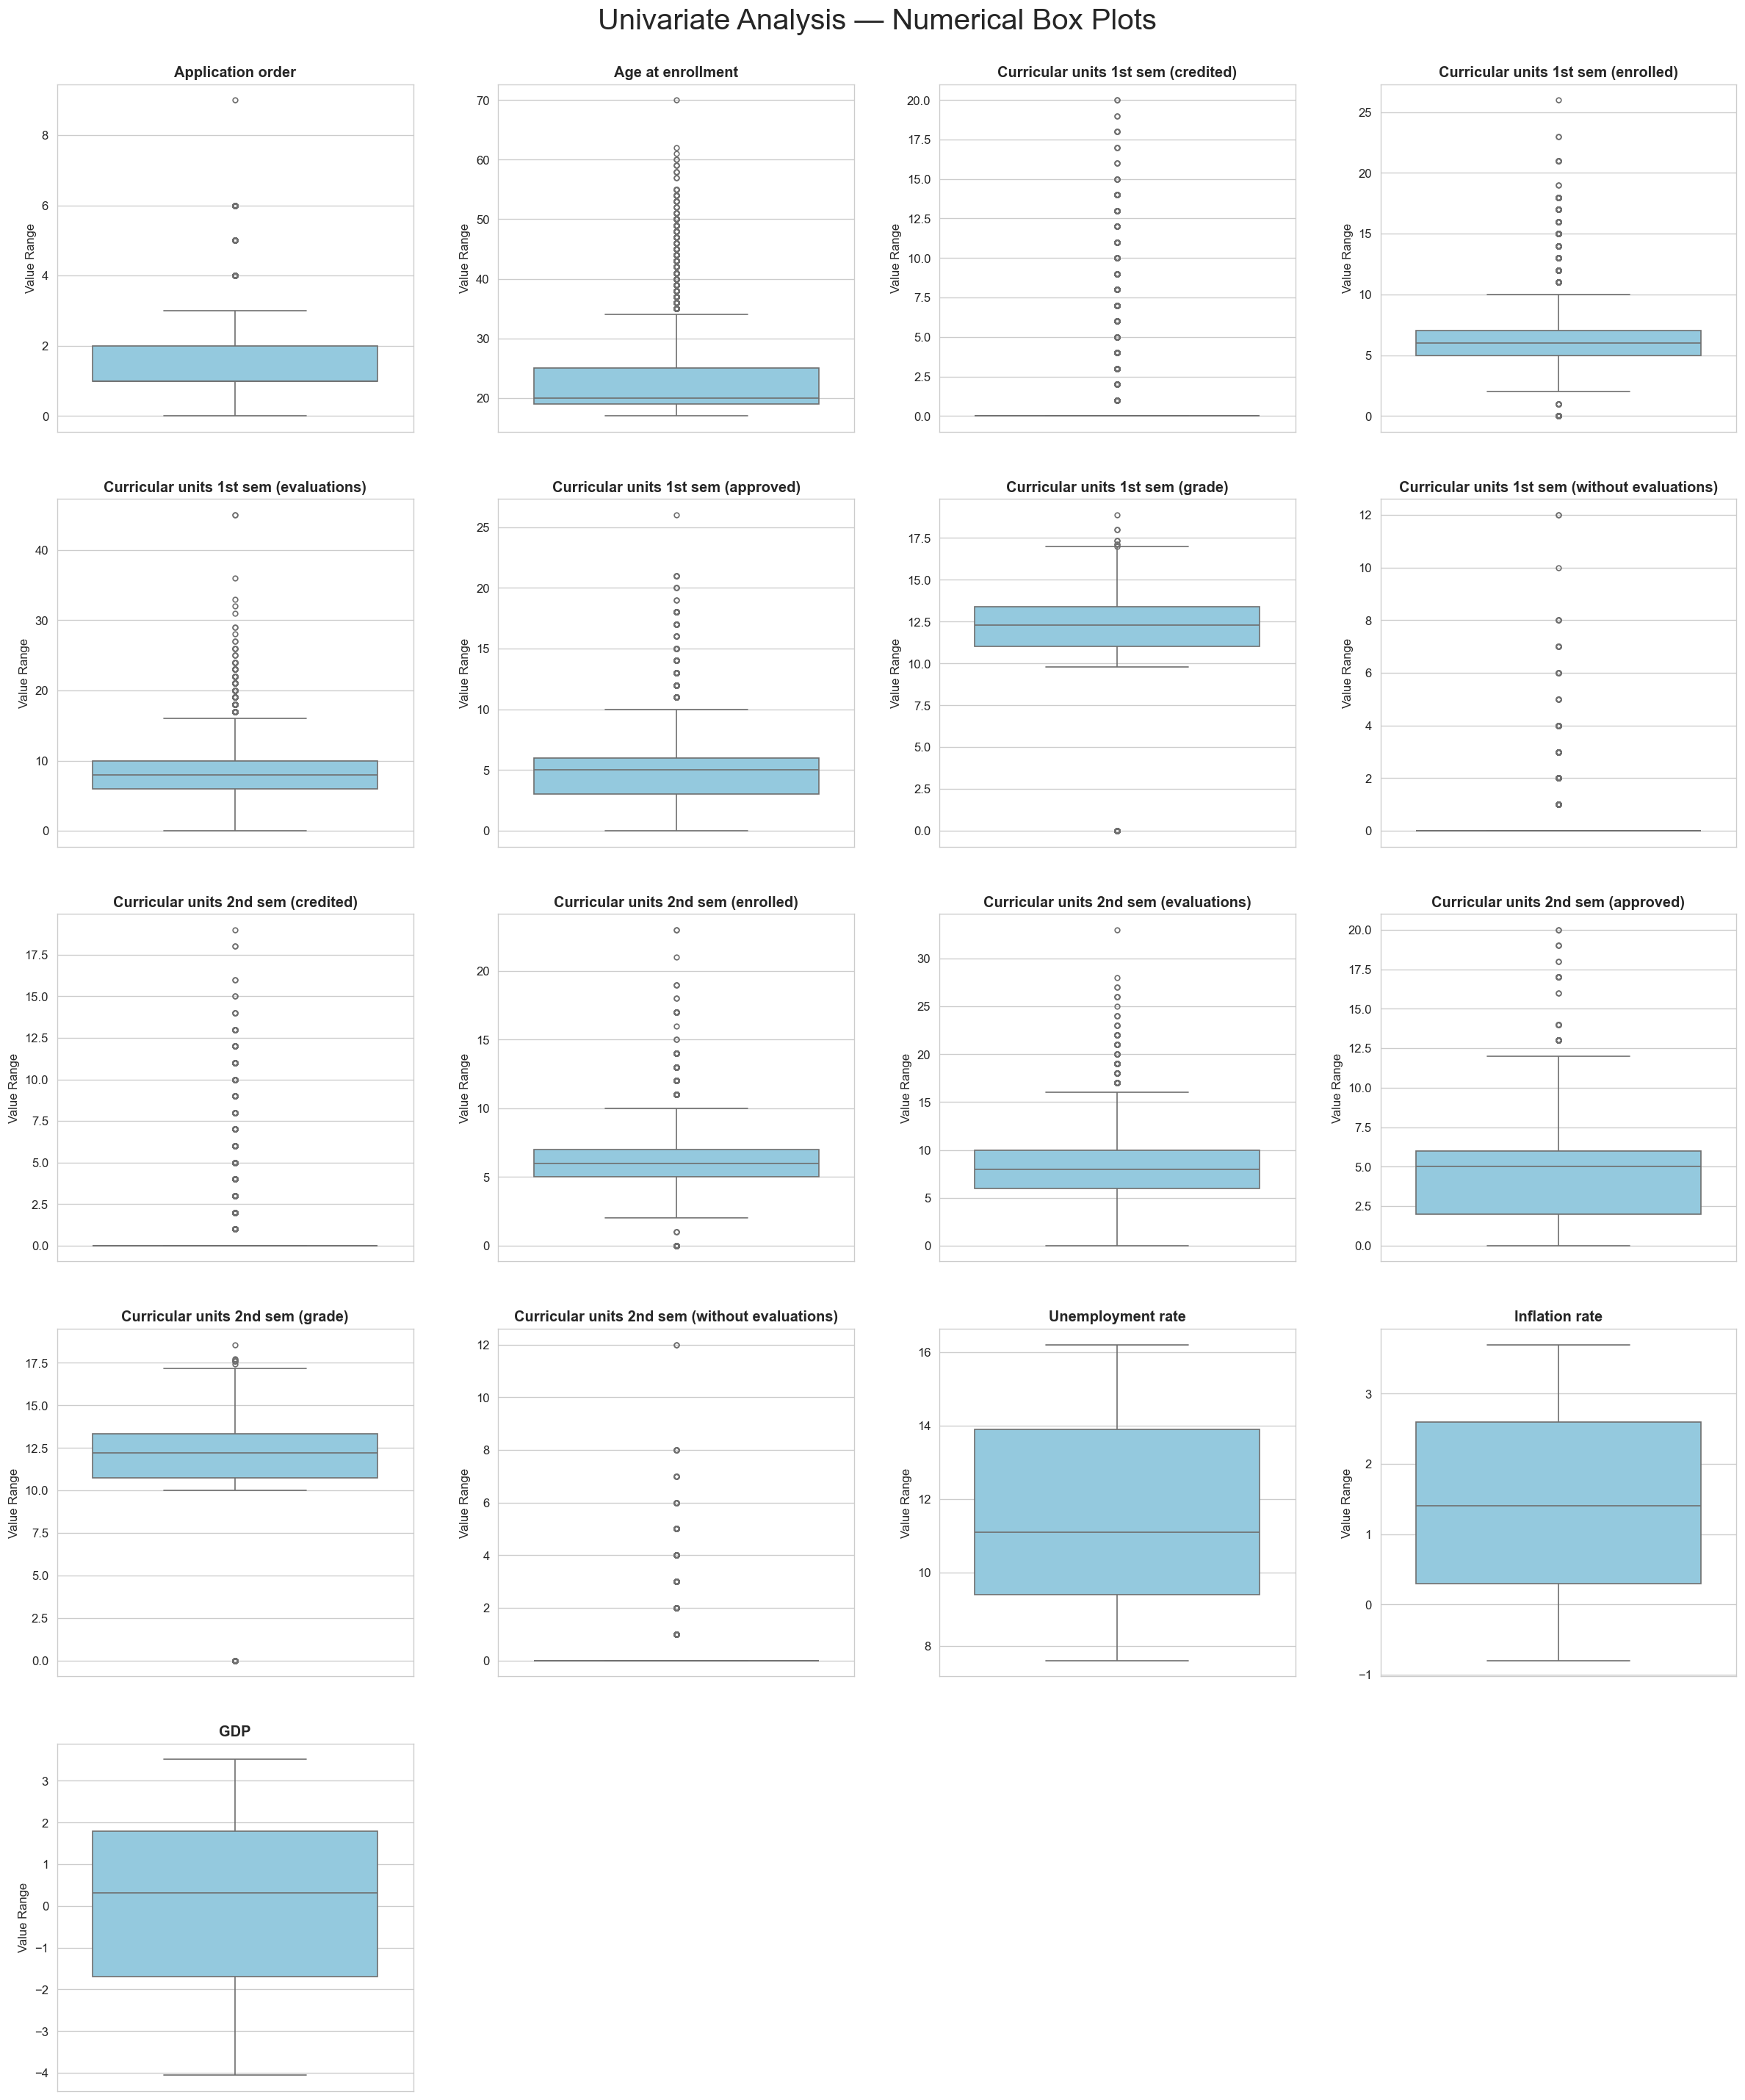

In [ ]:
# Univariate Analysis: Numerical Features (Box Plots)

# Setup the figure grid
n_cols = 4  
n_rows = (len(numerical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()


for i, col in enumerate(numerical_features):
    # Create the box plot
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue', fliersize=4)
    
    # Formatting
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value Range')
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.97], h_pad=4.0, w_pad=3.0)
plt.suptitle('Univariate Analysis — Numerical Box Plots', fontsize=24, y=0.99)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
numerical_boxplot_insights = {
    "1. Marital status": 
        """Observation: Minimal variance with a heavy concentration on 'Single' status.
        Key Insight: The population is demographically homogenous in this regard.
        Phase 3 Action: Maintain as categorical; check for low-frequency noise in smaller classes.""",

    "2. Application mode": 
        """Observation: Wide range of categories with several outliers representing rare entry methods.
        Key Insight: Entry paths are diverse, but most students follow a few common modes.
        Phase 3 Action: Use Target Encoding to handle the high cardinality of these entry modes.""",

    "3. Application order": 
        """Observation: Significant outliers above the 2nd preference, reaching up to 9.
        Key Insight: Most students get their first or second choice; high-order values are statistical exceptions.
        Phase 4 Action: Retain as is; higher values may indicate a 'fallback' student profile.""",

    "4. Course": 
        """Observation: Box plot shows distribution across all 17 courses with no specific outliers.
        Key Insight: Student distribution is relatively spread out across the available degrees.
        Phase 3 Action: No outlier removal needed; proceed with frequency or target encoding.""",

    "5. Daytime/evening attendance": 
        """Observation: Binary distribution; no outliers possible.
        Key Insight: Clear split between two distinct operational modes.
        Phase 3 Action: Keep as a binary flag.""",

    "6. Previous qualification": 
        """Observation: Several outliers sitting at higher education levels (Degree, Master's).
        Key Insight: Most students enter with secondary education; those with degrees are rare.
        Phase 3 Action: Do not remove; these 'advanced' students likely have different success rates.""",

    "7. Nationality": 
        """Observation: Extreme outliers for non-native nationalities.
        Key Insight: This feature has near-zero variance for the majority of the population.
        Phase 3 Action: Candidate for removal or conversion to a binary 'is_native' flag.""",

    "8. Mother's qualification": 
        """Observation: Broad distribution with outliers at the highest academic levels.
        Key Insight: Parental education varies but follows a consistent socio-economic trend.
        Phase 3 Action: Use Target Encoding to capture the risk associated with parental education.""",

    "9. Father's qualification": 
        """Observation: Similar to Mother's qualification; outliers at postgraduate levels.
        Key Insight: Redundant with Mother's qualification; likely highly correlated.
        Phase 3 Action: Consider feature engineering to combine parental education into a single metric.""",

    "10. Mother's occupation": 
        """Observation: High variance in professional status; no extreme outliers.
        Key Insight: Represents a broad socio-economic spectrum.
        Phase 3 Action: Target encoding to manage the categorical diversity.""",

    "11. Father's occupation": 
        """Observation: Consistent with Mother's occupation; high variance.
        Key Insight: Occupational data is the most 'spread out' categorical domain.
        Phase 3 Action: Target encoding to simplify for the model.""",

    "12. Displaced": 
        """Observation: Binary feature; no outliers.
        Key Insight: Nearly 50/50 split in the population.
        Phase 3 Action: High-quality predictor; keep as is.""",

    "13. Educational special needs": 
        """Observation: Isolated outliers in the 'Yes' category.
        Key Insight: Statistically insignificant frequency in this sample size.
        Phase 3 Action: Candidate for removal due to lack of variance.""",

    "14. Debtor": 
        """Observation: Significant outliers in the 'Yes' (1) category.
        Key Insight: Financial debt is a minority but impactful state.
        Phase 3 Action: High-priority predictor; do not remove or scale.""",

    "15. Tuition fees up to date": 
        """Observation: Binary; minority outliers in the 'No' (0) category.
        Key Insight: Direct indicator of administrative/financial standing.
        Phase 3 Action: Use as a key categorical feature for early warning models.""",

    "16. Gender": 
        """Observation: Binary; no outliers.
        Key Insight: Sufficiently balanced to provide a stable signal.
        Phase 3 Action: Keep as is.""",

    "17. Scholarship holder": 
        """Observation: Binary; outliers in the 'Yes' category.
        Key Insight: Approximately 1/4 of students receive financial support.
        Phase 3 Action: High importance feature for retention prediction.""",

    "18. Age at enrollment": 
        """Observation: Massive right-skew with outliers extending from 35 to 60+.
        Key Insight: Mature students are statistical outliers.
        Phase 3 Action: Apply Log Transformation to normalize the influence of older students.""",

    "19. International": 
        """Observation: Extreme isolated outliers for international status.
        Key Insight: Near-zero variance feature.
        Phase 3 Action: Remove to reduce model complexity.""",

    "20. Curricular units 1st sem (credited)": 
        """Observation: High-density outliers sitting above 0.
        Key Insight: Credited units are rare and indicate non-traditional entry.
        Phase 3 Action: Convert to a binary 'has_credits' flag.""",

    "21. Curricular units 1st sem (enrolled)": 
        """Observation: Outliers up to 25 units; median around 6.
        Key Insight: 'High-load' students are significant outliers.
        Phase 3 Action: Use RobustScaler to handle the high-end variance.""",

    "22. Curricular units 1st sem (evaluations)": 
        """Observation: Broad IQR with a long tail of outliers reaching 40+.
        Key Insight: Exam-taking behavior varies wildly beyond the standard load.
        Phase 3 Action: Retain; this is a key proxy for student engagement.""",

    "23. Curricular units 1st sem (approved)": 
        """Observation: Outliers at 0 and at high values (15-20).
        Key Insight: Failure (0) and extreme success are both 'outlier' states.
        Phase 3 Action: Do not remove; these are the primary predictors of the Target.""",

    "24. Curricular units 1st sem (grade)": 
        """Observation: Clean IQR with isolated 'failure' outliers at 0.0.
        Key Insight: 0.0 is a distinct state, not just a low grade.
        Phase 3 Action: Keep as is; handle the 0.0 spike with a binary flag.""",

    "25. Curricular units 1st sem (without evaluations)": 
        """Observation: Near-zero variance with rare outliers at 1-5.
        Key Insight: Most students take all their evaluations.
        Phase 3 Action: Remove due to low variance.""",

    "26. Curricular units 2nd sem (credited)": 
        """Observation: Mirror of 1st sem; high-density 0.0 with rare outliers.
        Key Insight: Credit recognition is static across semesters.
        Phase 3 Action: Likely redundant; drop in favor of 1st sem version.""",

    "27. Curricular units 2nd sem (enrolled)": 
        """Observation: Outliers at the high end (20+); median around 6.
        Key Insight: Administrative load remains stable for most.
        Phase 3 Action: Retain; compare with 1st sem for load changes.""",

    "28. Curricular units 2nd sem (evaluations)": 
        """Observation: Large number of outliers in the 15-30 range.
        Key Insight: Participation in exams is highly variable.
        Phase 3 Action: Standard scaling or Robust scaling required.""",

    "29. Curricular units 2nd sem (approved)": 
        """Observation: Significant outliers at 0 and above 12.
        Key Insight: The most critical predictor for graduation/dropout.
        Phase 3 Action: Do not remove; preserve the 0.0 status at all costs.""",

    "30. Curricular units 2nd sem (grade)": 
        """Observation: Normal IQR with a heavy 0.0 outlier spike.
        Key Insight: Confirms performance decay between semesters.
        Phase 3 Action: Keep; prioritize the 0.0 value in training.""",

    "31. Curricular units 2nd sem (without evaluations)": 
        """Observation: Near-zero variance; rare outliers.
        Key Insight: Statistically insignificant for most students.
        Phase 3 Action: Remove to simplify feature space.""",

    "32. Unemployment rate": 
        """Observation: Discrete distribution; no outliers.
        Key Insight: Macro-economic data is stable and structured.
        Phase 3 Action: No cleaning needed; keep as is.""",

    "33. Inflation rate": 
        """Observation: Balanced distribution; no outliers.
        Key Insight: Inflation variance is low and well-behaved.
        Phase 3 Action: No cleaning needed.""",

    "34. GDP": 
        """Observation: Small outliers at the extreme low (-4.0).
        Key Insight: Represents specific recession years in the dataset.
        Phase 3 Action: Keep; check if these 'recession' outliers correlate with higher dropouts.""",

    "35. Target": 
        """Observation: Categorical dependent variable; 3 distinct classes.
        Key Insight: Majority is Graduate; minority is Enrolled.
        Phase 3 Action: Use SMOTE to handle class imbalance in training."""
}

In [ ]:
phase_3_action_plan = {
    "1. Demographic Stagnation": {
        "Finding": "Nationality, International status, and Special Needs show near-zero variance.",
        "Action": "Remove these features to reduce noise and model complexity."
    },
    "2. High-Cardinality Categoricals": {
        "Finding": "Application mode and Occupations have too many categories (outliers in the 'rare' entry methods).",
        "Action": "Use Target Encoding to map these categories to the mean dropout rate per class."
    },
    "3. Financial & Academic Redundancy": {
        "Finding": "Parental qualifications/occupations and 1st/2nd semester credit data are highly correlated.",
        "Action": "Engineer composite features (e.g., 'Financial_Risk_Score') and drop redundant 2nd sem admin columns."
    },
    "4. Skewed Continuous Variables": {
        "Finding": "Age at enrollment is heavily right-skewed; Curricular units have extreme outlier tails (exam participation).",
        "Action": "Log-transform Age; apply RobustScaler to Curricular units to minimize outlier bias."
    },
    "5. The 'Zero' Signal": {
        "Finding": "0.0 grades in Curricular units are not just 'low'—they represent a distinct behavioral state (Dropout spike).",
        "Action": "Create a 'is_zero_sem1' binary flag to preserve this high-importance signal."
    },
    "6. Class Imbalance": {
        "Finding": "The 'Enrolled' status is a significant minority compared to 'Graduate'.",
        "Action": "Implement SMOTE in the modeling phase to prevent bias toward the majority class."
    },
    "7. Data Integrity Verification": {
        "Observation": "Systematic audit confirmed 0 missing values and 0 duplicate records across the entire dataset.",
        "Technical Insight": "The dataset is characterized by 100% completeness and perfect record independence.",
        "Implemented Action": "No corrective measures (Imputation or Deduplication) are required. The pipeline will proceed directly to feature transformation, ensuring 100% signal retention for Phase 3."
    }
}

print("PHASE 2: ACTION PLAN SUMMARY")
for key, content in phase_3_action_plan.items():
    print(f"\n{key.upper()}")
    for k, v in content.items():
        print(f"  > {k}: {v}")

PHASE 2: ACTION PLAN SUMMARY

1. DEMOGRAPHIC STAGNATION
  > Finding: Nationality, International status, and Special Needs show near-zero variance.
  > Action: Remove these features to reduce noise and model complexity.

2. HIGH-CARDINALITY CATEGORICALS
  > Finding: Application mode and Occupations have too many categories (outliers in the 'rare' entry methods).
  > Action: Use Target Encoding to map these categories to the mean dropout rate per class.

3. FINANCIAL & ACADEMIC REDUNDANCY
  > Finding: Parental qualifications/occupations and 1st/2nd semester credit data are highly correlated.
  > Action: Engineer composite features (e.g., 'Financial_Risk_Score') and drop redundant 2nd sem admin columns.

4. SKEWED CONTINUOUS VARIABLES
  > Finding: Age at enrollment is heavily right-skewed; Curricular units have extreme outlier tails (exam participation).
  > Action: Log-transform Age; apply RobustScaler to Curricular units to minimize outlier bias.

5. THE 'ZERO' SIGNAL
  > Finding: 0.0 g